In [ ]:
# =============================================
# IMPORTY
# =============================================
import math
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

from torch import nn
from pfns import utils
from pfns.model import bar_distribution
from pfns.train import train, MainConfig, OptimizerConfig, TransformerConfig, BatchShapeSamplerConfig
from pfns.model.encoders import EncoderConfig
from pfns.model.bar_distribution import BarDistributionConfig
from pfns.priors.prior import AdhocPriorConfig
from pfns.priors import Batch
from pfns.priors.fast_gp import get_batch as get_batch_for_gp

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✓ Device: {device}")
print(f"✓ PyTorch: {torch.__version__}")
# =============================================
# LOAD HELPER — funguje pro oba formáty checkpointů
# =============================================
import math

def load_pfn_model(checkpoint_path, device='cpu'):
    """
    Načte PFN model z checkpointu.
    Podporuje oba formáty:
      - novější (MainConfig dict, saved from epoch loop)
      - starší (simple hps dict, saved from train_gp_pfn())
    Vrací: (model, hps, epoch)
    """
    import os
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"Model nenalezen: {checkpoint_path}\n"
            "Nejdřív natrénuj model v train/PFN_TRAIN_SETUP.ipynb"
        )

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    config_data = checkpoint.get('config', {})

    # --- Novější formát: config obsahuje 'priors' (MainConfig dict) ---
    if isinstance(config_data, dict) and 'priors' in config_data:
        saved_config = MainConfig.from_dict(config_data)
        model = saved_config.model.create_model()
        model.load_state_dict(checkpoint['model_state_dict'])
        hps = saved_config.priors[0].prior_kwargs['hyperparameters']
        epoch = checkpoint.get('epoch', '?')

    # --- Starší formát: config obsahuje 'hps' (jednoduchý dict) ---
    elif isinstance(config_data, dict) and 'hps' in config_data:
        hps = config_data['hps']
        epoch = config_data.get('epochs', checkpoint.get('epoch', '?'))
        criterion = checkpoint['criterion']

        cfg = MainConfig(
            priors=[AdhocPriorConfig(
                get_batch_methods=[get_batch_for_gp],
                prior_kwargs={'num_features': 1, 'hyperparameters': hps}
            )],
            optimizer=OptimizerConfig('adamw', lr=0.0003),
            model=TransformerConfig(
                criterion=BarDistributionConfig(
                    full_support=True,
                    borders=criterion.borders.tolist()
                ),
                emsize=512, nhead=8, nhid=1024, nlayers=6,
                features_per_group=1,
                attention_between_features=False,
                encoder=EncoderConfig(
                    constant_normalization_mean=0.5,
                    constant_normalization_std=math.sqrt(1/12)
                )
            ),
            batch_shape_sampler=BatchShapeSamplerConfig(
                batch_size=64, max_seq_len=50,
                min_num_features=1, max_num_features=1
            ),
            epochs=20, warmup_epochs=5,
            steps_per_epoch=100, num_workers=0,
        )
        model = cfg.model.create_model()
        model.load_state_dict(checkpoint['model_state_dict'])

    else:
        raise ValueError(f"Neznámý formát checkpointu. Nalezené klíče: {list(config_data.keys())}")

    model.to(device)
    model.eval()
    return model, hps, epoch


In [ ]:
# =============================================
# NAČTENÍ MODELU
# =============================================

checkpoint_path = os.path.join('models', 'pfn_gp_model_20.pth')
loaded_model, hps, epoch = load_pfn_model(checkpoint_path, device)

print(f'✓ Model načten (epocha {epoch})')
print(f'  GP params: {hps}')
print(f'  Parametrů: {sum(p.numel() for p in loaded_model.parameters()) / 1e6:.2f}M')


Mounted at /content/drive
Loading model from /content/drive/MyDrive/UZNATONEMAMNERVY/PFN_GP_model/pfn_gp_model.pth...
Config: hps={'noise': 0.0001, 'outputscale': 1.0, 'lengthscale': 0.3}, num_features=1, max_dataset_size=50
Vytvářím strukturu modelu...
init dist
Not using distributed
ALL: Using device cpu.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<pfns.priors.fast_gp.get_batch (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, equidistant_x=False, fix_x=None, **kwargs)
), num_features=1, hyperparameters={'noise': 0.0001, 'outputscale': 1.0, 'lengthscale': 0.3}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=50, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'cpu', 'n_targets_per_inpu

/content/PFNs/pfns/train.py:238: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = GradScaler() if c.train_mixed_precision else None


-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  2.72s | mean loss  1.39 | lr 0.0 | data time  0.08 step time  2.63 forward time  0.51 | max gpu mem N/A GiB | gpu utilization N/A %| nan share  0.00 ignore share (for classification tasks) 0.0000 
-----------------------------------------------------------------------------------------
✓ Model úspěšně načten!


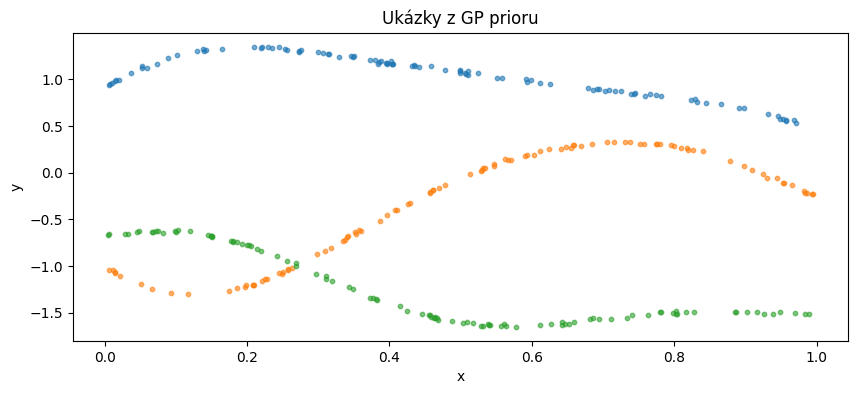

Batch shapes: x=torch.Size([3, 100, 1]), y=torch.Size([3, 100])


In [ ]:
# =============================================
# GP PRIOR - Sampling funkce
# =============================================

# Ukázka dat z GP prioru
hps_gp = {"noise": 1e-4, "outputscale": 1., "lengthscale": 0.3}

batch = get_batch_for_gp(batch_size=3, seq_len=100, num_features=1, hyperparameters=hps)

plt.figure(figsize=(10, 4))
for i in range(len(batch.x)):
    plt.scatter(batch.x[i, :, 0].cpu().numpy(), batch.y[i, :].cpu().numpy(), alpha=0.6, s=10)
plt.title('Ukázky z GP prioru')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

print(f"Batch shapes: x={batch.x.shape}, y={batch.y.shape}")

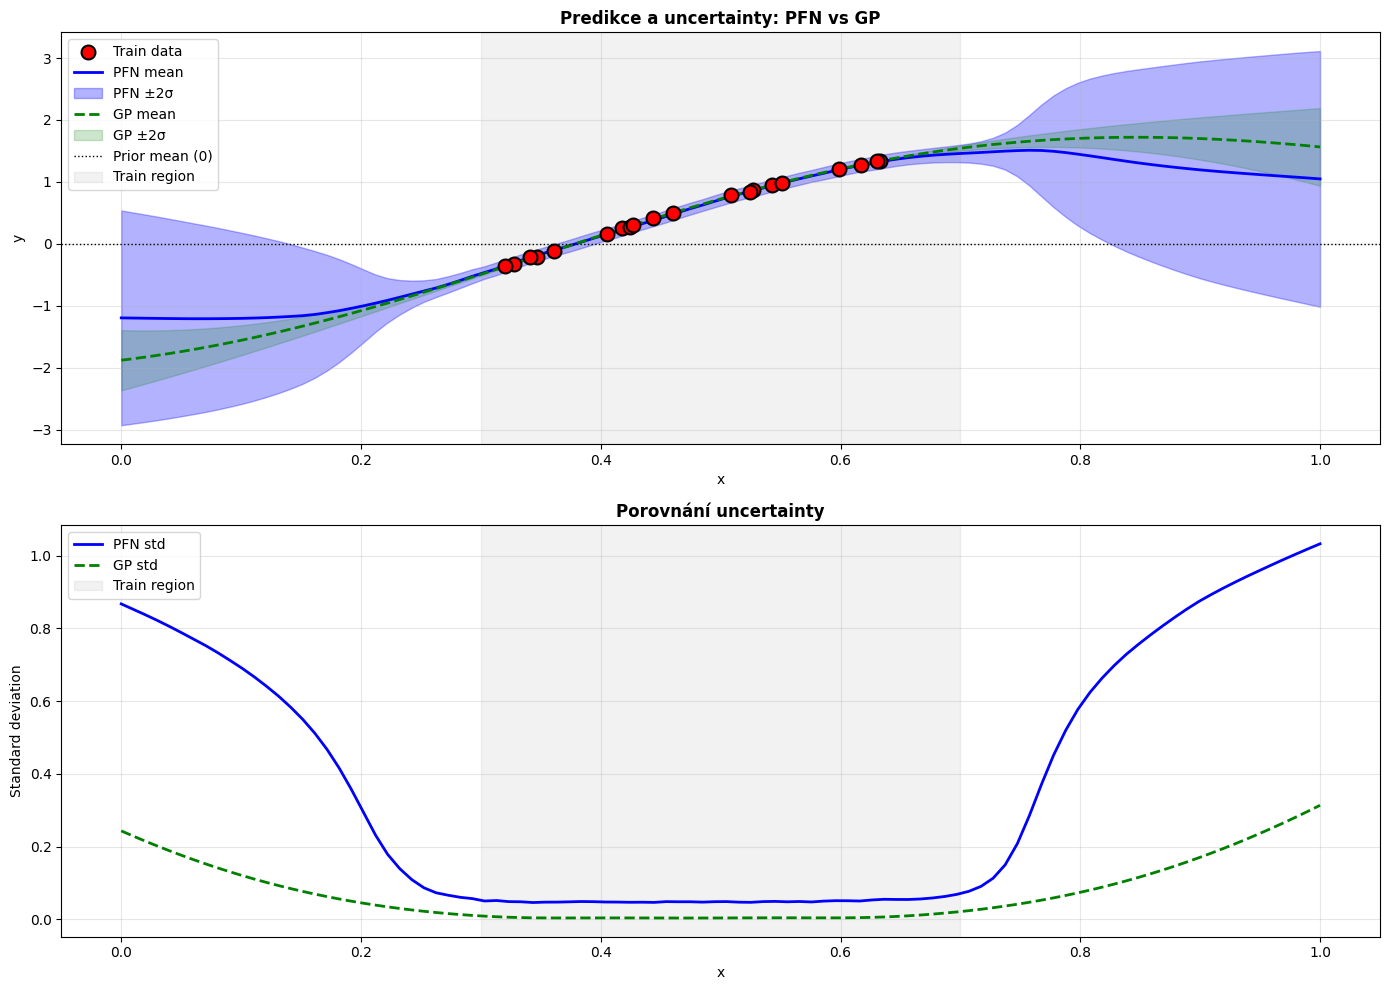


=== TEST 1: Konvergence mean funkce ===
Trial 0:
  Train data mean: 0.51
  PFN mean (far): 0.01, (near): 0.69
  GP mean (far):  0.06, (near): 0.71
  PFN converges to train mean: True
  GP converges to train mean:  True
Trial 1:
  Train data mean: 2.56
  PFN mean (far): 1.12, (near): 2.75
  GP mean (far):  1.25, (near): 2.62
  PFN converges to train mean: False
  GP converges to train mean:  False
Trial 2:
  Train data mean: -0.52
  PFN mean (far): -0.04, (near): -0.57
  GP mean (far):  -0.18, (near): -0.63
  PFN converges to train mean: True
  GP converges to train mean:  True
Trial 3:
  Train data mean: 0.28
  PFN mean (far): 0.34, (near): 0.22
  GP mean (far):  0.42, (near): 0.23
  PFN converges to train mean: True
  GP converges to train mean:  True
Trial 4:
  Train data mean: 0.75
  PFN mean (far): 0.14, (near): 0.67
  GP mean (far):  0.13, (near): 0.70
  PFN converges to train mean: True
  GP converges to train mean:  True

=== TEST 2: Správnost variance ===
Trial 0:
  Correlatio

In [ ]:
# =============================================
# EXPERIMENT 1: Konvergence k prioru a variance
# =============================================

def test_prior_convergence_and_variance(model, hps, n_trials=10):
    results = []

    for trial in range(n_trials):
        batch = get_batch_for_gp(batch_size=1, seq_len=100, num_features=1, hyperparameters=hps)

        train_mask = (batch.x[0, :, 0] >= 0.3) & (batch.x[0, :, 0] <= 0.7)
        train_indices = torch.where(train_mask)[0][:20]

        train_x = batch.x[0, train_indices]
        train_y = batch.y[0, train_indices]

        test_x = torch.linspace(0, 1, 100).unsqueeze(1).to(batch.x.device)

        # PFN predikce
        with torch.no_grad():
            logits = model(train_x[None], train_y[None], test_x[None])

        pfn_means = model.criterion.mean(logits)[0].cpu().numpy()
        pfn_variance = model.criterion.variance(logits)[0].cpu().numpy()
        pfn_std = np.sqrt(pfn_variance)

        # GP predikce
        from sklearn.gaussian_process import GaussianProcessRegressor
        from sklearn.gaussian_process.kernels import RBF, ConstantKernel

        kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=hps['lengthscale'])
        gp = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
        gp.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
        gp_mean, gp_std = gp.predict(test_x.cpu().numpy(), return_std=True)

        results.append({
            'test_x': test_x.cpu().numpy().flatten(),
            'train_x': train_x.cpu().numpy().flatten(),
            'train_y': train_y.cpu().numpy().flatten(),  # ← PŘIDÁNO!
            'pfn_mean': pfn_means,
            'pfn_std': pfn_std,
            'gp_mean': gp_mean,
            'gp_std': gp_std,
        })

    return results


# Spusť test
results = test_prior_convergence_and_variance(loaded_model, hps, n_trials=5)

# Vizualizace jednoho příkladu
res = results[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Mean + uncertainty bands
ax = axes[0]

# Train data
ax.scatter(res['train_x'], res['train_y'],
           c='red', s=100, zorder=10, label='Train data', marker='o', edgecolors='black', linewidths=1.5)

# PFN prediction
ax.plot(res['test_x'], res['pfn_mean'], 'b-', lw=2, label='PFN mean')
ax.fill_between(res['test_x'],
                 res['pfn_mean'] - 2*res['pfn_std'],
                 res['pfn_mean'] + 2*res['pfn_std'],
                 alpha=0.3, color='blue', label='PFN ±2σ')

# GP prediction
ax.plot(res['test_x'], res['gp_mean'], 'g--', lw=2, label='GP mean')
ax.fill_between(res['test_x'],
                 res['gp_mean'] - 2*res['gp_std'],
                 res['gp_mean'] + 2*res['gp_std'],
                 alpha=0.2, color='green', label='GP ±2σ')

# Prior mean (0)
ax.axhline(y=0, color='black', linestyle=':', lw=1, label='Prior mean (0)')

# Zvýrazni train region
ax.axvspan(0.3, 0.7, alpha=0.1, color='gray', label='Train region')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Predikce a uncertainty: PFN vs GP', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Comparison of uncertainties
ax = axes[1]

ax.plot(res['test_x'], res['pfn_std'], 'b-', lw=2, label='PFN std')
ax.plot(res['test_x'], res['gp_std'], 'g--', lw=2, label='GP std')
ax.axvspan(0.3, 0.7, alpha=0.1, color='gray', label='Train region')

ax.set_xlabel('x')
ax.set_ylabel('Standard deviation')
ax.set_title('Porovnání uncertainty', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# === KVANTITATIVNÍ TESTY ===

print("\n=== TEST 1: Konvergence mean funkce ===")
for i, res in enumerate(results):
    far_mask = (res['test_x'] < 0.2) | (res['test_x'] > 0.8)
    near_mask = (res['test_x'] >= 0.4) & (res['test_x'] <= 0.6)

    # Mean hodnoty daleko vs blízko
    pfn_mean_far = np.mean(res['pfn_mean'][far_mask])
    pfn_mean_near = np.mean(res['pfn_mean'][near_mask])
    gp_mean_far = np.mean(res['gp_mean'][far_mask])
    gp_mean_near = np.mean(res['gp_mean'][near_mask])

    # Empirický mean z train dat
    train_mean = np.mean(res['train_y'])

    print(f"Trial {i}:")
    print(f"  Train data mean: {train_mean:.2f}")
    print(f"  PFN mean (far): {pfn_mean_far:.2f}, (near): {pfn_mean_near:.2f}")
    print(f"  GP mean (far):  {gp_mean_far:.2f}, (near): {gp_mean_near:.2f}")
    print(f"  PFN converges to train mean: {abs(pfn_mean_far - train_mean) < 1.0}")
    print(f"  GP converges to train mean:  {abs(gp_mean_far - train_mean) < 1.0}")

print("\n=== TEST 2: Správnost variance ===")
for i, res in enumerate(results):
    # Korelace mezi PFN a GP std
    corr = np.corrcoef(res['pfn_std'], res['gp_std'])[0, 1]

    # MSE mezi std
    mse_std = np.mean((res['pfn_std'] - res['gp_std'])**2)

    # Poměr std daleko vs blízko
    far_mask = (res['test_x'] < 0.2) | (res['test_x'] > 0.8)
    near_mask = (res['test_x'] >= 0.4) & (res['test_x'] <= 0.6)

    pfn_ratio = np.mean(res['pfn_std'][far_mask]) / np.mean(res['pfn_std'][near_mask])
    gp_ratio = np.mean(res['gp_std'][far_mask]) / np.mean(res['gp_std'][near_mask])

    print(f"Trial {i}:")
    print(f"  Correlation PFN vs GP std: {corr:.4f}")
    print(f"  MSE(PFN std, GP std): {mse_std:.6f}")
    print(f"  PFN uncertainty ratio (far/near): {pfn_ratio:.2f}")
    print(f"  GP uncertainty ratio (far/near): {gp_ratio:.2f}")

* Experiment testoval PFN na extrapolaci: trénovací data pouze v regionu x=0.3-0.7, testovací data v celém rozsahu x=0.0-1.0.

* PFN aproximuje mean predikce téměř perfektně, modrá a zelená křivka jsou téměř identické na obou stranách train regionu.

* PFN má významný problém s uncertainty estimation při extrapolaci mimo train region.

* Konkrétní čísla uncertainty: PFN má std=0.95 daleko od dat vs GP std=0.37, PFN má std=0.05 blízko dat vs GP std=0.01.

* PFN má příliš vysokou baseline uncertainty všude a příliš malý dynamický rozsah: ratio far/near je 19x pro PFN vs 37x pro GP.

* Korelace mezi PFN a GP uncertainty je vysoká (0.94-0.96), což znamená že PFN rozpoznává správný pattern, ale má špatná absolutní čísla.

* Hlavní příčina problému je to, že training distribution obsahovala pouze uniform coverage přes celý prostor, PFN nikdy neviděl scénář se sparse coverage v malém regionu.

* Druhou možnou příčinou je, že BarDistribution má hard limit na maximum variance kvůli fixed bins, nemůže vyjádřit extrémní uncertainty.

* Model byl trénován pouze 20 epoch (4000 kroků), training loss stále klesal, model je pravděpodobně nedotrénovaný (ale pravděpodobně to nezlepší situaci s extropolaci).

* PFN funguje výborně pro interpolaci (test data mezi train daty), ale má špatnou calibraci pro extrapolaci (test data mimo train region).


In [ ]:
# =============================================
# EXPERIMENT 2: Zkoumání Attention vah
# =============================================
import torch.nn.functional as F

def compute_attention_weights(model, train_x, train_y, test_x):
    """
    Zachytí vstupy do attention a manuálně vypočítá attention váhy.
    """
    model.eval()

    layer_inputs = []

    def input_hook(module, inputs, output):
        layer_inputs.append(inputs[0].detach().cpu())

    # Hook na attention vrstvy
    hooks = []
    attn_modules = []
    for name, module in model.named_modules():
        if 'self_attn_between_items' in name and 'self_attn_between_items.' not in name:
            hooks.append(module.register_forward_hook(input_hook))
            attn_modules.append(module)

    with torch.no_grad():
        _ = model(train_x[None], train_y[None], test_x[None])

    for hook in hooks:
        hook.remove()

    # Vypočítej attention váhy pro každou vrstvu
    all_attention_weights = []

    for layer_idx, module in enumerate(attn_modules):
        if layer_idx >= len(layer_inputs):
            break

        x = layer_inputs[layer_idx]
        w_qkv = module.w_qkv.cpu()

        batch, features, seq_len, embed_dim = x.shape
        n_heads = w_qkv.shape[1]
        head_dim = w_qkv.shape[2]

        x_flat = x.reshape(-1, embed_dim)

        W_q = w_qkv[0]
        W_k = w_qkv[1]

        W_q_t = W_q.permute(2, 0, 1)
        W_k_t = W_k.permute(2, 0, 1)

        Q = torch.matmul(x_flat, W_q_t.reshape(embed_dim, -1)).reshape(-1, n_heads, head_dim)
        K = torch.matmul(x_flat, W_k_t.reshape(embed_dim, -1)).reshape(-1, n_heads, head_dim)

        Q = Q.reshape(batch, features, seq_len, n_heads, head_dim)
        K = K.reshape(batch, features, seq_len, n_heads, head_dim)

        Q = Q.permute(0, 1, 3, 2, 4)
        K = K.permute(0, 1, 3, 2, 4)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (head_dim ** 0.5)
        attn_weights = F.softmax(scores, dim=-1)

        all_attention_weights.append(attn_weights)

    return all_attention_weights, layer_inputs

# Test
batch = get_batch_for_gp(batch_size=1, seq_len=50, num_features=1, hyperparameters=hps)
n_context = 20

train_x = batch.x[0, :n_context]
train_y = batch.y[0, :n_context]
test_x = batch.x[0]

attn_weights, layer_inputs = compute_attention_weights(loaded_model, train_x, train_y, test_x)

print(f"Počet vrstev: {len(attn_weights)}")
for i, w in enumerate(attn_weights):
    print(f"Vrstva {i}: attention shape = {w.shape}")

Počet vrstev: 6
Vrstva 0: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 1: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 2: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 3: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 4: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 5: attention shape = torch.Size([1, 1, 8, 70, 70])


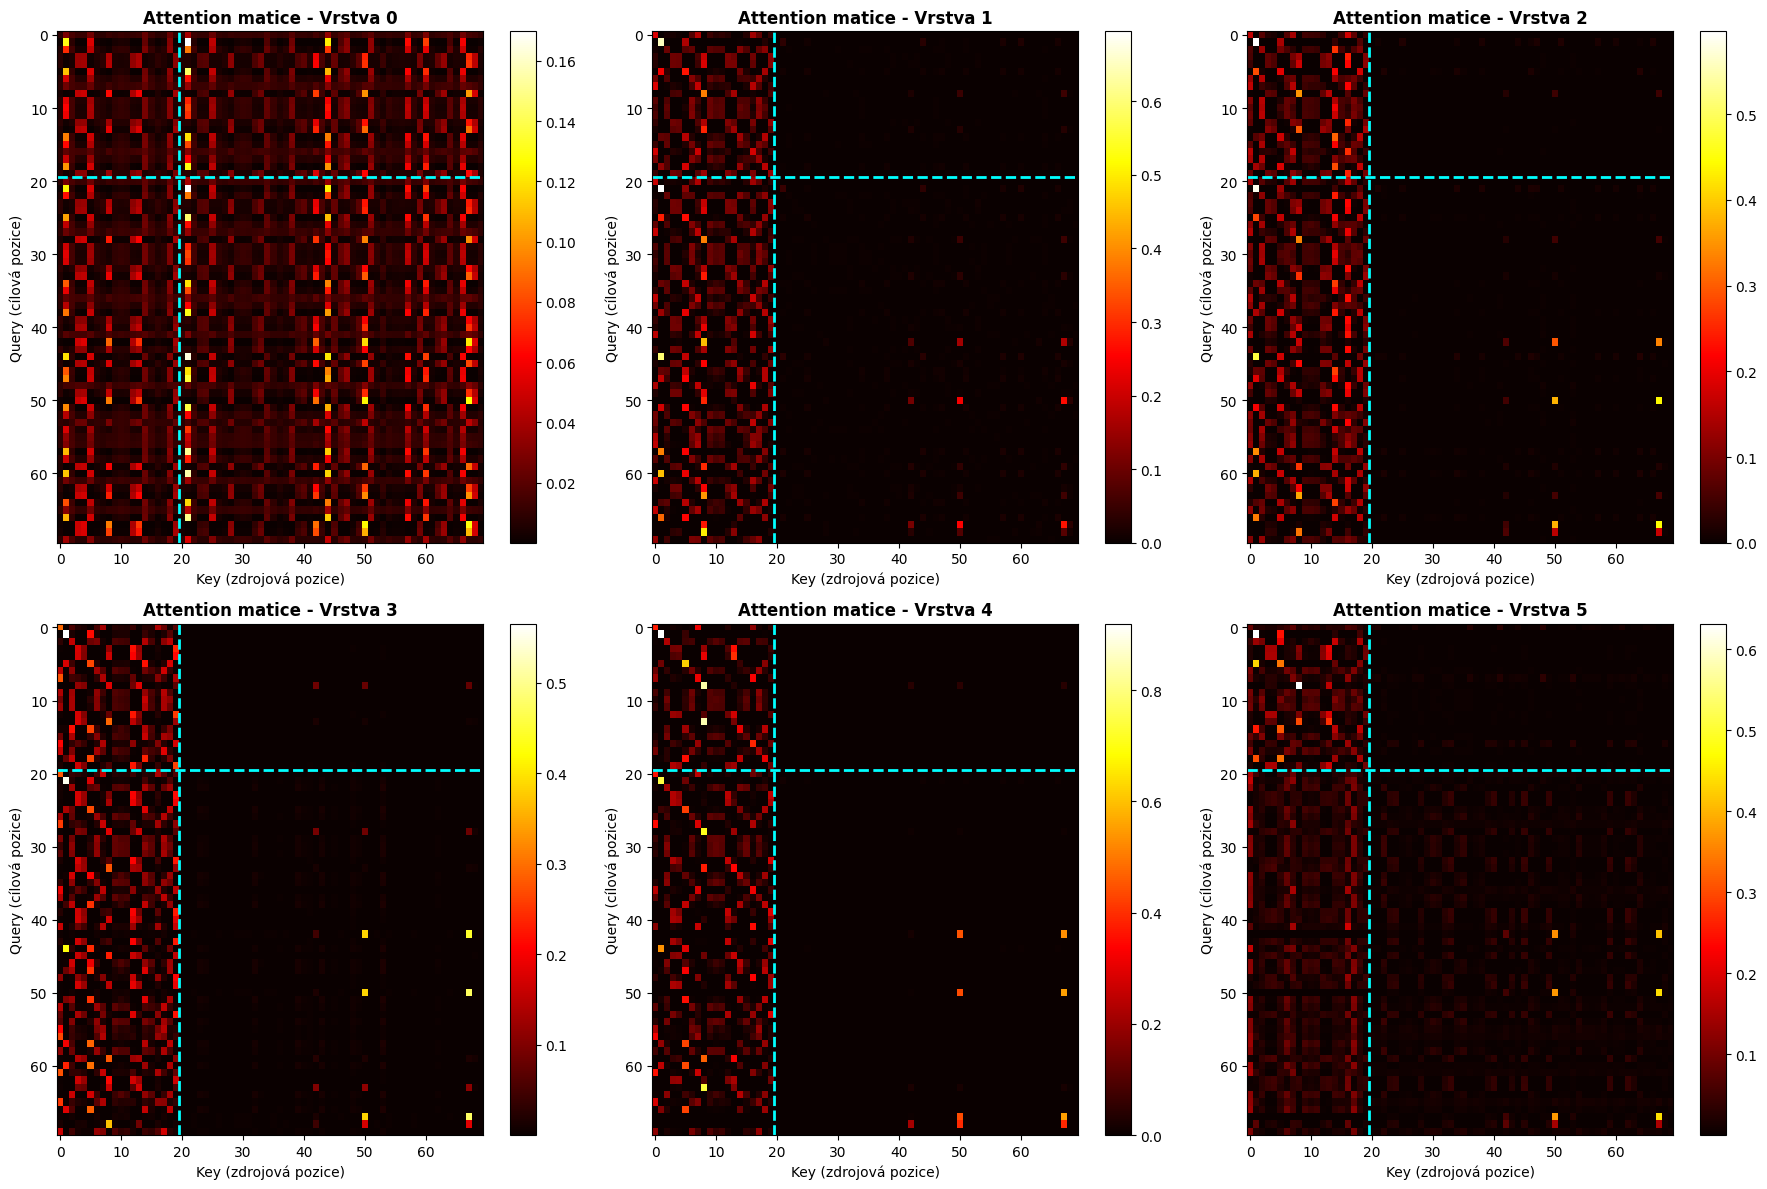

In [ ]:
# =============================================
# VIZUALIZACE ATTENTION VAH
# =============================================

fig1, axes1 = plt.subplots(2, 3, figsize=(18, 12))
axes1 = axes1.flatten()

for layer_idx in range(6):
    # Průměr přes všechny heads
    attn_layer = attn_weights[layer_idx][0, 0].mean(dim=0).detach().numpy()  # [seq_len, seq_len]

    ax = axes1[layer_idx]
    im = ax.imshow(attn_layer, cmap='hot', aspect='auto')
    ax.axhline(y=n_context-0.5, color='cyan', linestyle='--', lw=2)
    ax.axvline(x=n_context-0.5, color='cyan', linestyle='--', lw=2)
    ax.set_xlabel('Key (zdrojová pozice)')
    ax.set_ylabel('Query (cílová pozice)')
    ax.set_title(f'Attention matice - Vrstva {layer_idx}', fontweight='bold')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()




*   Zde je ukázka attention matic pro různé vrstvy, díky níž můžeme pozorovat, zda transformer se naučil nějaký konkretní pattern, nebo naučil se složitější struktury.
*   Každá matice je rozdělená na kvadranty podle počtu trénovaících a testovacích bodů a jejich vzajemných vztahů, tj. jak na sebe navzájem davají pozor.

* Vlevo nahoře : Train→Train attention,

  vpravo nahoře: Train→Test attention,

  vlevo dole: Test→Train attention,

  vpravo dole: Test→Test attention.

* Je vidět, že transformer postupně odhalil, že trénovací data nezávísí na testovacích a testovací data nějakým způsobem závísí na trénovacích datech. Což je zcela sprváná logika, kterou transformer dokázal odhalit sám.

* Struktura těchto matic je vlastně náznákem, že PFN dělá Bayesian inference, ne jen pattern matching. Kdyby se PFN jen učil nazpaměť trénovací data, attention by byla symetrická — všechny kvadranty podobně aktivní.


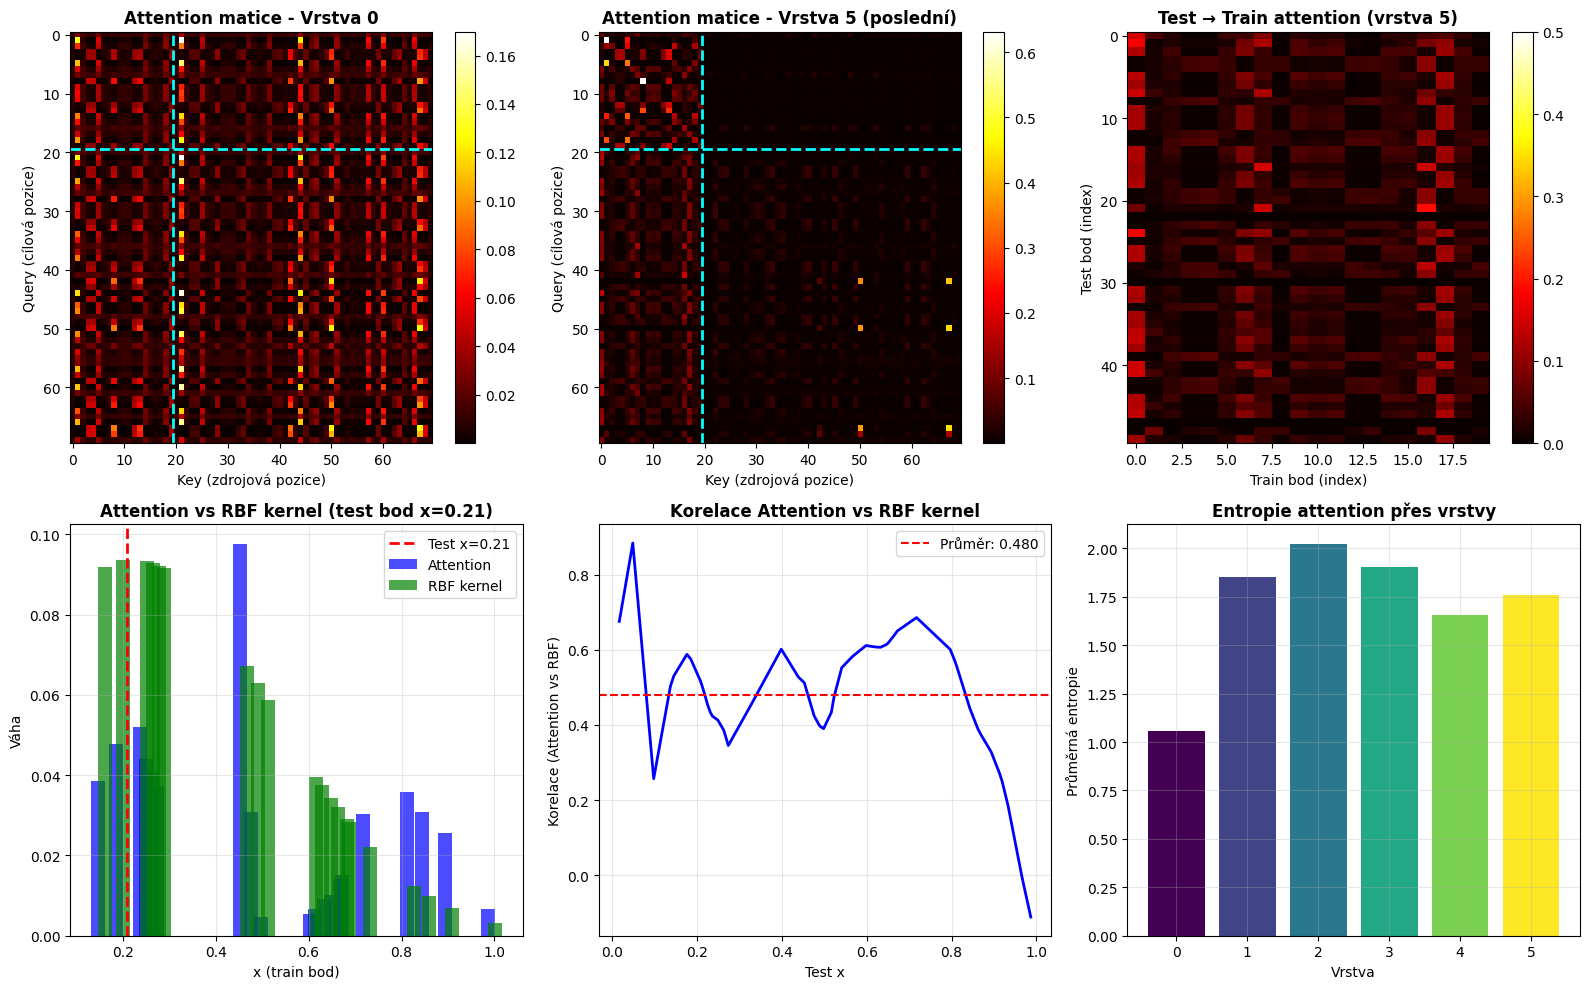


Průměrná korelace Attention vs RBF: 0.4802
Vyšší korelace = PFN se naučil kernel-like chování


In [ ]:
# Průměr přes všechny heads
attn_layer0 = attn_weights[0][0, 0].mean(dim=0).detach().numpy()  # [70, 70]
attn_layer5 = attn_weights[5][0, 0].mean(dim=0).detach().numpy()  # [70, 70]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Attention matice - vrstva 0
ax = axes[0, 0]
im = ax.imshow(attn_layer0, cmap='hot', aspect='auto')
ax.axhline(y=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.axvline(x=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.set_xlabel('Key (zdrojová pozice)')
ax.set_ylabel('Query (cílová pozice)')
ax.set_title('Attention matice - Vrstva 0', fontweight='bold')
plt.colorbar(im, ax=ax)

# 2. Attention matice - vrstva 5 (poslední)
ax = axes[0, 1]
im = ax.imshow(attn_layer5, cmap='hot', aspect='auto')
ax.axhline(y=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.axvline(x=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.set_xlabel('Key (zdrojová pozice)')
ax.set_ylabel('Query (cílová pozice)')
ax.set_title('Attention matice - Vrstva 5 (poslední)', fontweight='bold')
plt.colorbar(im, ax=ax)

# 3. Jak test body attendují na train body (vrstva 5)
# Test body jsou indexy n_context:70, train body jsou 0:n_context
test_to_train_attn = attn_layer5[n_context:, :n_context]  # [50, 20]

ax = axes[0, 2]
# DŮLEŽITÉ: použij STEJNÝ rozsah jako vlevo (vmin, vmax)
im = ax.imshow(test_to_train_attn, cmap='hot', aspect='auto',
               vmin=0, vmax=0.5)  # ← PŘIDÁNO
#              ^^^^^^^^^^^^^^
ax.set_xlabel('Train bod (index)')
ax.set_ylabel('Test bod (index)')
ax.set_title('Test → Train attention (vrstva 5)', fontweight='bold')
plt.colorbar(im, ax=ax)

# 4. Attention vs RBF kernel pro jeden test bod
test_idx = 25  # Nějaký test bod (index v test sekvenci)
test_x_val = test_x[test_idx, 0].cpu().item()

# Attention váhy tohoto test bodu na train body
attn_to_train = attn_layer5[n_context + test_idx, :n_context]

# RBF kernel váhy
train_x_np = train_x[:, 0].cpu().numpy()
rbf_weights = np.exp(-0.5 * (train_x_np - test_x_val)**2 / hps['lengthscale']**2)
rbf_weights_norm = rbf_weights / rbf_weights.sum()

# Seřaď podle x
order = np.argsort(train_x_np)

ax = axes[1, 0]
ax.bar(train_x_np[order], attn_to_train[order], width=0.03, alpha=0.7, label='Attention', color='blue')
ax.bar(train_x_np[order] + 0.015, rbf_weights_norm[order], width=0.03, alpha=0.7, label='RBF kernel', color='green')
ax.axvline(x=test_x_val, color='red', linestyle='--', lw=2, label=f'Test x={test_x_val:.2f}')
ax.set_xlabel('x (train bod)')
ax.set_ylabel('Váha')
ax.set_title(f'Attention vs RBF kernel (test bod x={test_x_val:.2f})', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Korelace attention vs RBF pro všechny test body
correlations = []
for i in range(len(test_x)):
    test_x_val = test_x[i, 0].cpu().item()
    attn_to_train = attn_layer5[n_context + i, :n_context]

    rbf_weights = np.exp(-0.5 * (train_x_np - test_x_val)**2 / hps['lengthscale']**2)
    rbf_weights_norm = rbf_weights / rbf_weights.sum()

    corr = np.corrcoef(attn_to_train, rbf_weights_norm)[0, 1]
    correlations.append(corr)

ax = axes[1, 1]
test_x_sorted_idx = test_x[:, 0].cpu().argsort()
ax.plot(test_x[test_x_sorted_idx, 0].cpu().numpy(), np.array(correlations)[test_x_sorted_idx], 'b-', lw=2)
ax.set_xlabel('Test x')
ax.set_ylabel('Korelace (Attention vs RBF)')
ax.set_title('Korelace Attention vs RBF kernel', fontweight='bold')
ax.axhline(y=np.mean(correlations), color='red', linestyle='--', label=f'Průměr: {np.mean(correlations):.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Vývoj attention přes vrstvy
ax = axes[1, 2]
for layer_idx in range(6):
    attn_layer = attn_weights[layer_idx][0, 0].mean(dim=0).detach().numpy()
    test_to_train = attn_layer[n_context:, :n_context]

    # Průměrná "ostrost" attention (entropie)
    entropy = -np.sum(test_to_train * np.log(test_to_train + 1e-10), axis=1).mean()
    ax.bar(layer_idx, entropy, color=plt.cm.viridis(layer_idx/5))

ax.set_xlabel('Vrstva')
ax.set_ylabel('Průměrná entropie')
ax.set_title('Entropie attention přes vrstvy', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPrůměrná korelace Attention vs RBF: {np.mean(correlations):.4f}")
print(f"Vyšší korelace = PFN se naučil kernel-like chování")



*   Z detailního průzkumu kvadrantu Test→Train attention v poslední vrstvě je vidět, že PFN nedělá jenom lokální kernel averaging. Kdyby attention byla kernel-like (Nadaraya-Watson), pozorovali bychom pattern v tomto kvadrantu matice. To co my skutečně vidíme je skoro uniformní rozdělení attention mezi body, tj. PFN se naučil aproximovat GP spolu s kernelovou funkci, tj. attention váhy nejsou určené jen vzdáleností (x' - x_train), ale bere v úvahu korelační strukturu mezi train body.
*  Na grafu Attention vs RBF kernel můžeme pozorovat, jaký vliv na konkrétní testovací bod mají jeho okolní body a jak tetno vliv počítá PFN vs RBF. Je zjevné, že PFN se nanučil jenom RBF kernel k(x', x), ale celé GP váhy k(x', x) @ K^{-1}.

* Stejný závěr platí i při pozorování grafu Korelace Attention vs RBF kernel, je vidět, že v některých místech ta korelace může být i záporná.

* Na posledním grafu je znázorněna entropie přes jednotlivé vrstvy. Opět PFN se nenaučil pouze nějaké patterny v datech, on se naučil něco složitějšího.



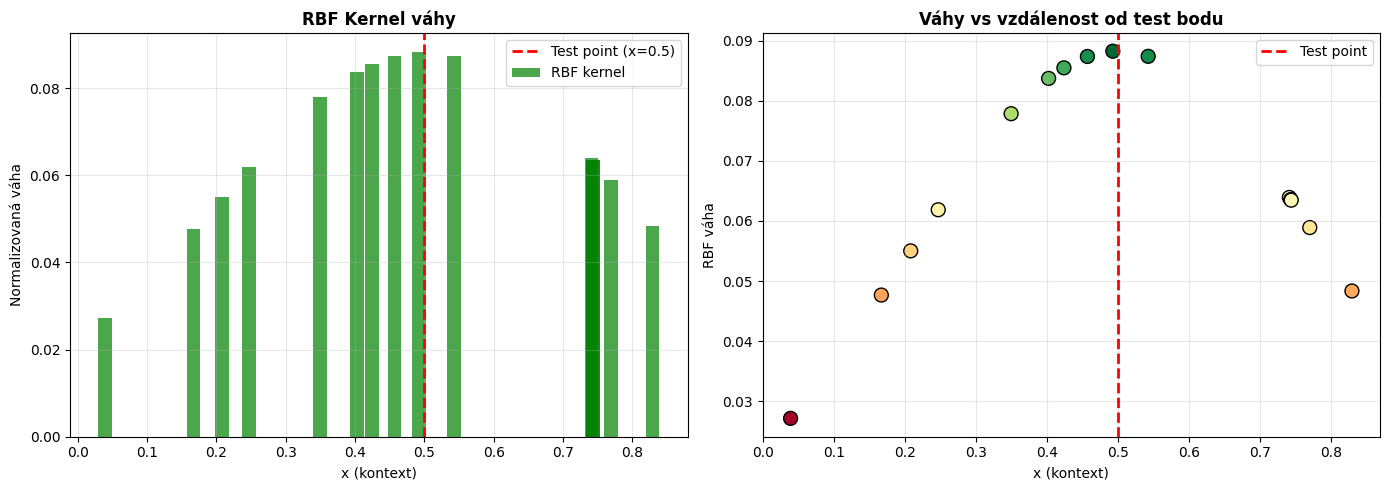

Body blízko x=0.5 mají vyšší váhu (kernel smoothing)


In [ ]:
# =============================================
# EXPERIMENT 3: Porovnání Attention z PFN vs RBF Kernel
# =============================================
# Hypotéza: Attention váhy by měly korelovat s RBF kernelem

def compute_rbf_kernel(x1, x2, lengthscale=0.3):
    """Vypočítá RBF kernel matrix."""
    x1 = x1.cpu().numpy().reshape(-1, 1) if torch.is_tensor(x1) else x1.reshape(-1, 1)
    x2 = x2.cpu().numpy().reshape(-1, 1) if torch.is_tensor(x2) else x2.reshape(-1, 1)

    # ||x1 - x2||^2
    dist_sq = np.sum(x1**2, axis=1, keepdims=True) + np.sum(x2**2, axis=1) - 2 * x1 @ x2.T
    return np.exp(-0.5 * dist_sq / lengthscale**2)

def compute_attention_similarity(model, train_x, train_y, test_point):
    """
    Aproximuje attention váhy pomocí dot-product similarity embeddings.
    """
    model.eval()

    # Získej embeddings pro všechny body
    all_x = torch.cat([train_x, test_point.unsqueeze(0)], dim=0)
    all_y = torch.cat([train_y, torch.zeros(1).to(train_y.device)], dim=0)

    # Hook pro zachycení embeddings po první vrstvě
    embeddings = []
    def embedding_hook(module, input, output):
        embeddings.append(output.detach().cpu())

    # Najdi encoder vrstvu
    hook = None
    for name, module in model.named_modules():
        if 'encoder' in name.lower() and hasattr(module, 'weight'):
            hook = module.register_forward_hook(embedding_hook)
            break

    with torch.no_grad():
        _ = model(all_x[None], all_y[None], all_x[None])

    if hook:
        hook.remove()

    return embeddings

# Generuj data
batch = get_batch_for_gp(batch_size=1, seq_len=30, num_features=1, hyperparameters=hps)
n_context = 15

train_x = batch.x[0, :n_context, 0]  # (n_context,)
train_y = batch.y[0, :n_context]
test_point = torch.tensor([0.5]).to(train_x.device)

# RBF kernel mezi test bodem a train body
rbf_weights = compute_rbf_kernel(test_point.cpu().numpy(), train_x.cpu().numpy(), lengthscale=hps['lengthscale'])
rbf_weights = rbf_weights.flatten()
rbf_weights_norm = rbf_weights / rbf_weights.sum()  # Normalizuj jako softmax

# Seřaď podle x pro vizualizaci
order = train_x.cpu().argsort()
train_x_sorted = train_x.cpu()[order].numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RBF kernel váhy
ax = axes[0]
ax.bar(train_x_sorted, rbf_weights_norm[order], width=0.02, alpha=0.7, color='green', label='RBF kernel')
ax.axvline(x=0.5, color='red', linestyle='--', lw=2, label='Test point (x=0.5)')
ax.set_xlabel('x (kontext)')
ax.set_ylabel('Normalizovaná váha')
ax.set_title('RBF Kernel váhy', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Porovnání s GP predikcí - váhy by měly být podobné
ax = axes[1]
# Vizualizace: body blíže k test pointu mají vyšší váhu
distances = np.abs(train_x_sorted - 0.5)
ax.scatter(train_x_sorted, rbf_weights_norm[order], c=distances, cmap='RdYlGn_r', s=100, edgecolor='black')
ax.axvline(x=0.5, color='red', linestyle='--', lw=2, label='Test point')
ax.set_xlabel('x (kontext)')
ax.set_ylabel('RBF váha')
ax.set_title('Váhy vs vzdálenost od test bodu', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Body blízko x=0.5 mají vyšší váhu (kernel smoothing)")

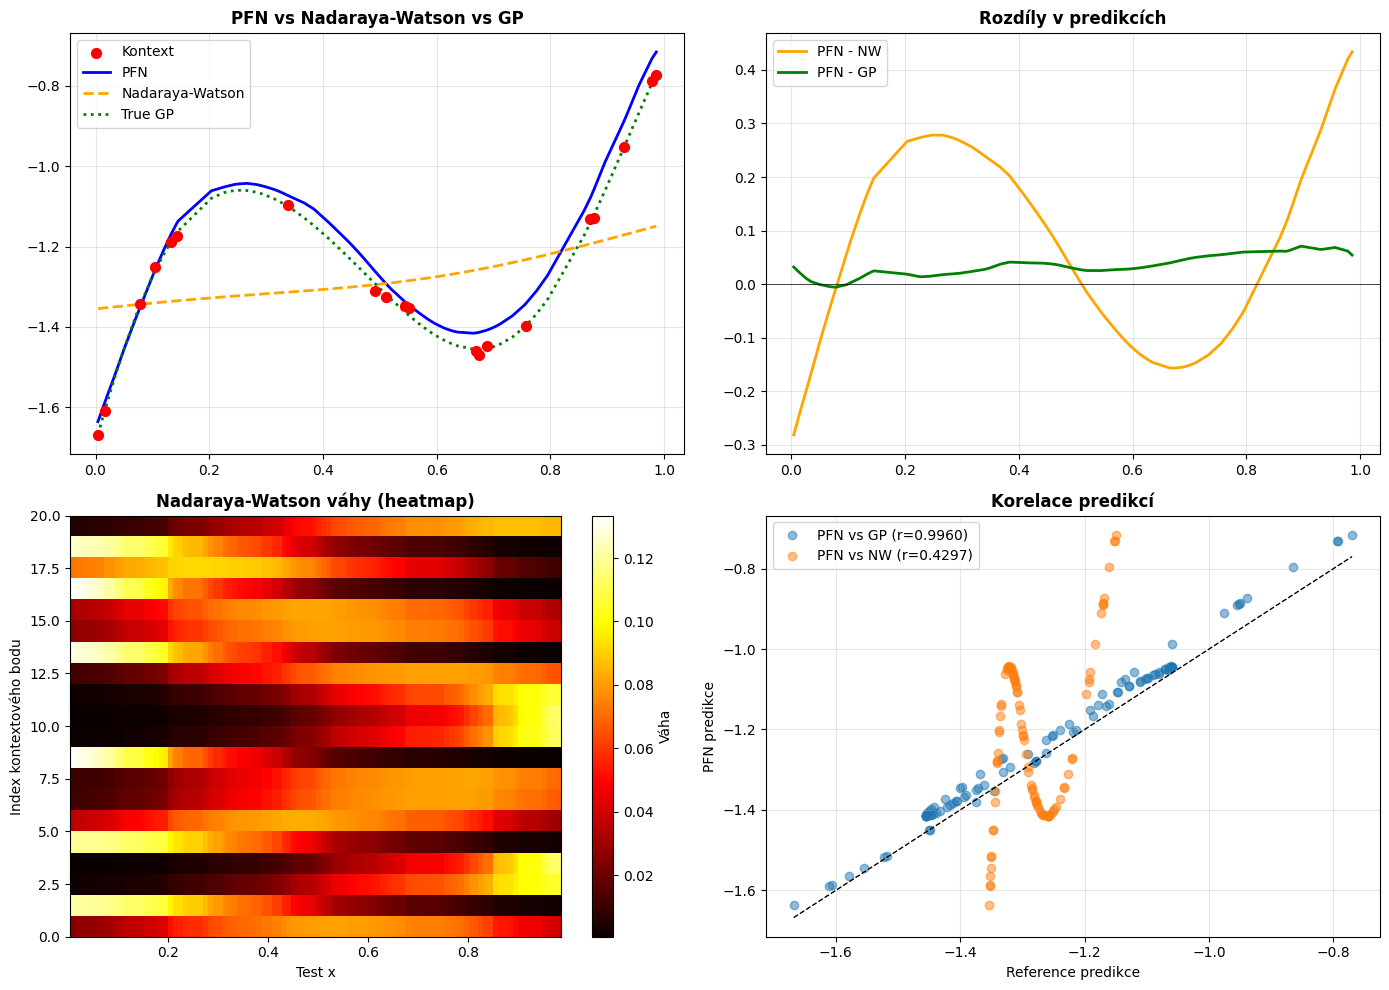

MSE PFN vs GP: 0.001431
MSE PFN vs NW: 0.037635
MSE NW vs GP:  0.034370


In [ ]:
# =============================================
# EXPERIMENT 4: Porovnání GP vs PFN vs RBF
# =============================================
# PFN ~ Nadaraya-Watson estimátor: y_pred = sum(w_i * y_i)

def nadaraya_watson_prediction(train_x, train_y, test_x, lengthscale=0.3):
    """
    Nadaraya-Watson kernel estimátor - to co by měl PFN aproximovat.
    """
    train_x_np = train_x.cpu().numpy().reshape(-1)
    train_y_np = train_y.cpu().numpy().reshape(-1)
    test_x_np = test_x.cpu().numpy().reshape(-1)

    predictions = []
    all_weights = []

    for x_test in test_x_np:
        # RBF váhy
        weights = np.exp(-0.5 * (train_x_np - x_test)**2 / lengthscale**2)
        weights_norm = weights / weights.sum()

        # Vážený průměr
        y_pred = np.sum(weights_norm * train_y_np)
        predictions.append(y_pred)
        all_weights.append(weights_norm)

    return np.array(predictions), np.array(all_weights)

# Generuj data
batch = get_batch_for_gp(batch_size=1, seq_len=100, num_features=1, hyperparameters=hps)
n_context = 20

train_x = batch.x[0, :n_context, 0]
train_y = batch.y[0, :n_context]
test_x = batch.x[0, :, 0]

# PFN predikce
with torch.no_grad():
    logits = loaded_model(batch.x[0, :n_context][None], train_y[None], batch.x[0][None])
pfn_means = loaded_model.criterion.mean(logits)[0].cpu().numpy()

# Nadaraya-Watson predikce
nw_preds, nw_weights = nadaraya_watson_prediction(train_x, train_y, test_x, lengthscale=hps['lengthscale'])

# True GP
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=hps['lengthscale'])
gp = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
gp.fit(train_x.cpu().numpy().reshape(-1, 1), train_y.cpu().numpy())
gp_mean = gp.predict(test_x.cpu().numpy().reshape(-1, 1))

# Seřaď
order = test_x.cpu().argsort()
test_x_sorted = test_x.cpu()[order].numpy()

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Porovnání predikcí
ax = axes[0, 0]
ax.scatter(train_x.cpu(), train_y.cpu(), c='red', s=50, zorder=10, label='Kontext')
ax.plot(test_x_sorted, pfn_means[order], 'b-', lw=2, label='PFN')
ax.plot(test_x_sorted, nw_preds[order], 'orange', lw=2, linestyle='--', label='Nadaraya-Watson')
ax.plot(test_x_sorted, gp_mean[order], 'g:', lw=2, label='True GP')
ax.set_title('PFN vs Nadaraya-Watson vs GP', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Rozdíl PFN vs NW
ax = axes[0, 1]
diff_nw = pfn_means[order] - nw_preds[order]
diff_gp = pfn_means[order] - gp_mean[order]
ax.plot(test_x_sorted, diff_nw, 'orange', lw=2, label='PFN - NW')
ax.plot(test_x_sorted, diff_gp, 'green', lw=2, label='PFN - GP')
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_title('Rozdíly v predikcích', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Heatmapa NW vah
ax = axes[1, 0]
im = ax.imshow(nw_weights[order].T, aspect='auto', cmap='hot',
               extent=[test_x_sorted.min(), test_x_sorted.max(), 0, n_context])
ax.set_xlabel('Test x')
ax.set_ylabel('Index kontextového bodu')
ax.set_title('Nadaraya-Watson váhy (heatmap)', fontweight='bold')
plt.colorbar(im, ax=ax, label='Váha')

# 4. Korelace
ax = axes[1, 1]
ax.scatter(gp_mean, pfn_means, alpha=0.5, label=f'PFN vs GP (r={np.corrcoef(gp_mean, pfn_means)[0,1]:.4f})')
ax.scatter(nw_preds, pfn_means, alpha=0.5, label=f'PFN vs NW (r={np.corrcoef(nw_preds, pfn_means)[0,1]:.4f})')
ax.plot([gp_mean.min(), gp_mean.max()], [gp_mean.min(), gp_mean.max()], 'k--', lw=1)
ax.set_xlabel('Reference predikce')
ax.set_ylabel('PFN predikce')
ax.set_title('Korelace predikcí', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MSE PFN vs GP: {np.mean((pfn_means - gp_mean)**2):.6f}")
print(f"MSE PFN vs NW: {np.mean((pfn_means - nw_preds)**2):.6f}")
print(f"MSE NW vs GP:  {np.mean((nw_preds - gp_mean)**2):.6f}")



*   Tady jsou další ukázky porovnání N-W predikcí s PFN a jak moc dobře odpovídají skutečným predikcím GP




n_context=5: MSE=0.006431 ± 0.009301
n_context=10: MSE=0.006403 ± 0.017220
n_context=20: MSE=0.001512 ± 0.001880
n_context=30: MSE=0.002888 ± 0.007395
n_context=50: MSE=0.000973 ± 0.000745


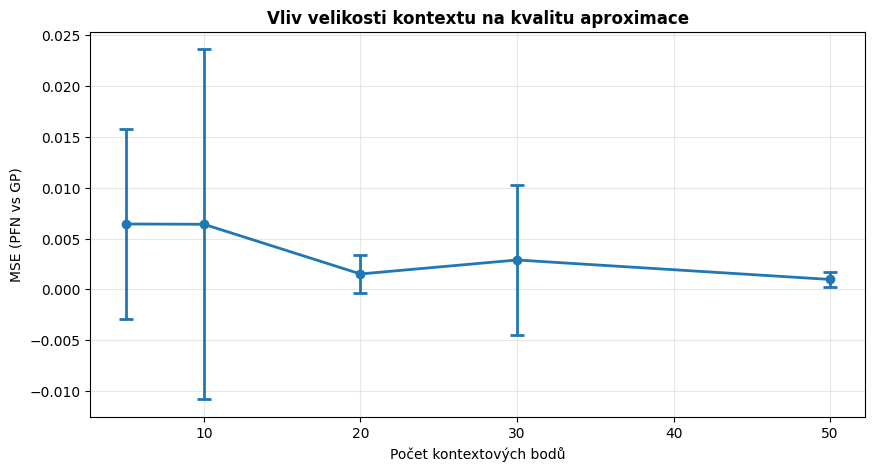

In [ ]:
# =============================================
# EXPERIMENT 5: Jak počet vrstev ovlivňuje aproximaci?
# =============================================
# Hypotéza: Více vrstev = lepší aproximace inverze kernel matice

# Toto vyžaduje modifikovaný model nebo přístup k mezivýstupům
# Pro teď vizualizujeme efekt počtu kontextových bodů

def analyze_context_size_effect(model, hps, context_sizes=[5, 10, 20, 30, 50]):
    """
    Analyzuje jak počet kontextových bodů ovlivňuje kvalitu aproximace.
    """
    results = []

    for n_ctx in context_sizes:
        mses = []
        for _ in range(20):  # 20 opakování
            batch = get_batch_for_gp(batch_size=1, seq_len=100, num_features=1, hyperparameters=hps)

            train_x = batch.x[0, :n_ctx]
            train_y = batch.y[0, :n_ctx]
            test_x = batch.x[0]

            # PFN
            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_means = model.criterion.mean(logits)[0].cpu().numpy()

            # GP
            kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=hps['lengthscale'])
            gp = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
            gp.fit(train_x.cpu().numpy().reshape(-1, 1), train_y.cpu().numpy())
            gp_mean = gp.predict(test_x.cpu()[..., 0].numpy().reshape(-1, 1))

            mse = np.mean((pfn_means - gp_mean)**2)
            mses.append(mse)

        results.append({
            'n_context': n_ctx,
            'mse_mean': np.mean(mses),
            'mse_std': np.std(mses)
        })
        print(f"n_context={n_ctx}: MSE={np.mean(mses):.6f} ± {np.std(mses):.6f}")

    return results

results = analyze_context_size_effect(loaded_model, hps)

# Vizualizace
fig, ax = plt.subplots(figsize=(10, 5))
n_ctx = [r['n_context'] for r in results]
mse_mean = [r['mse_mean'] for r in results]
mse_std = [r['mse_std'] for r in results]

ax.errorbar(n_ctx, mse_mean, yerr=mse_std, marker='o', capsize=5, capthick=2, lw=2)
ax.set_xlabel('Počet kontextových bodů')
ax.set_ylabel('MSE (PFN vs GP)')
ax.set_title('Vliv velikosti kontextu na kvalitu aproximace', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.show()

EXPERIMENT 6: Jedna attention hlava vs Nadaraya-Watson

--- Detailní vizualizace pro vybrané hlavy ---


=== VRSTVA 0, HLAVA 0 ===
Korelace attention vs RBF kernel: 0.1947

MSE (Mean Squared Error):
  Single head vs NW:  0.727658
  Single head vs PFN: 0.837585
  Single head vs GP:  0.920542
  NW vs GP:           0.095672
  Full PFN vs GP:     0.002529


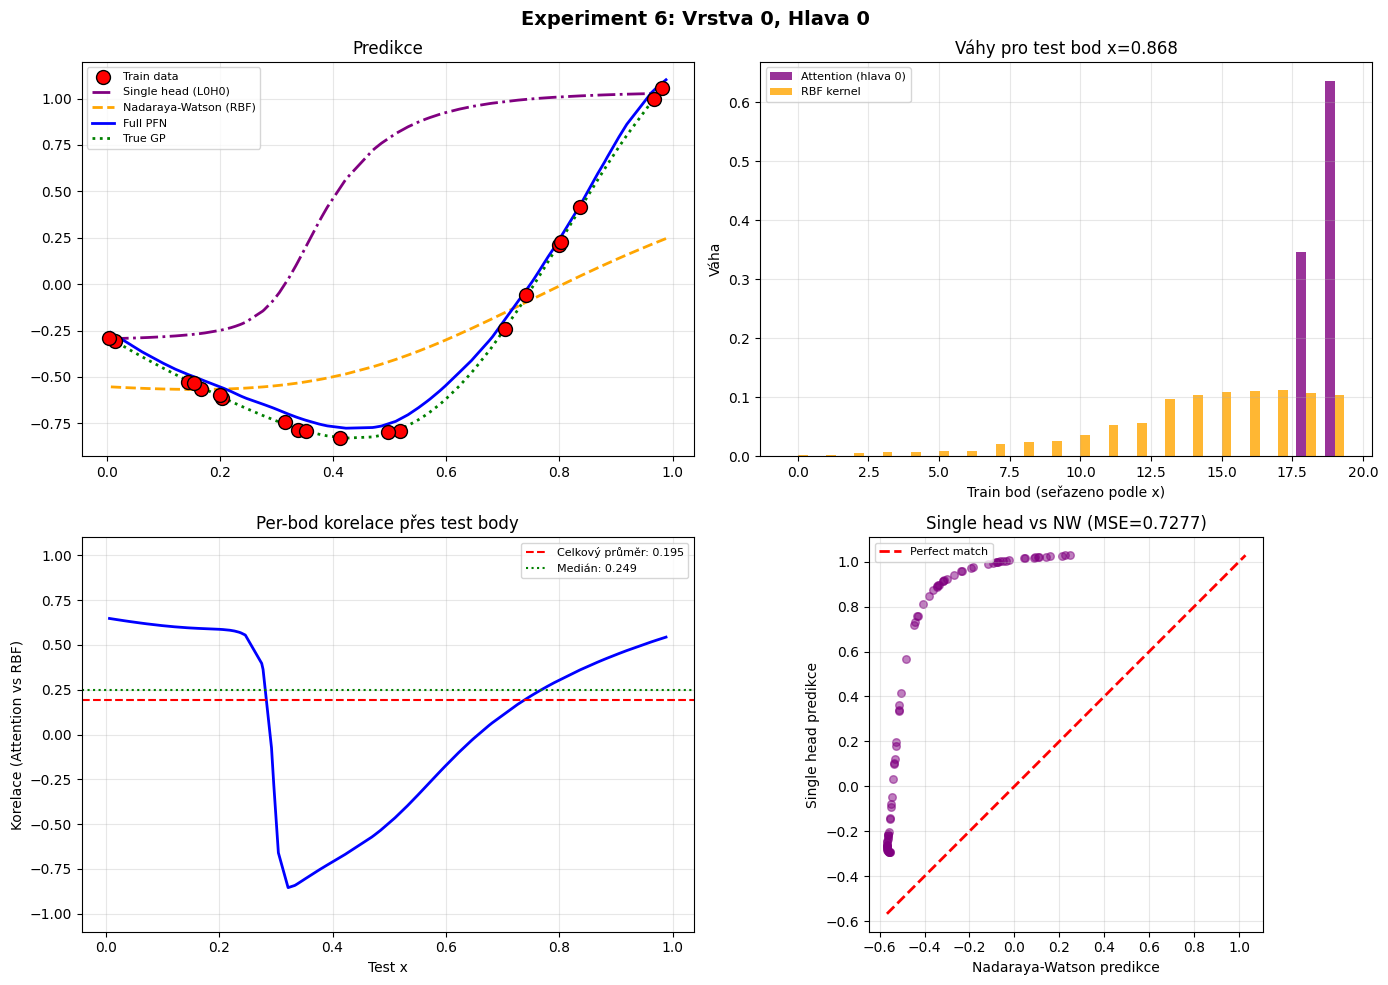


=== VRSTVA 0, HLAVA 3 ===
Korelace attention vs RBF kernel: 0.6684

MSE (Mean Squared Error):
  Single head vs NW:  0.059526
  Single head vs PFN: 0.476111
  Single head vs GP:  0.493718
  NW vs GP:           0.269141
  Full PFN vs GP:     0.000927


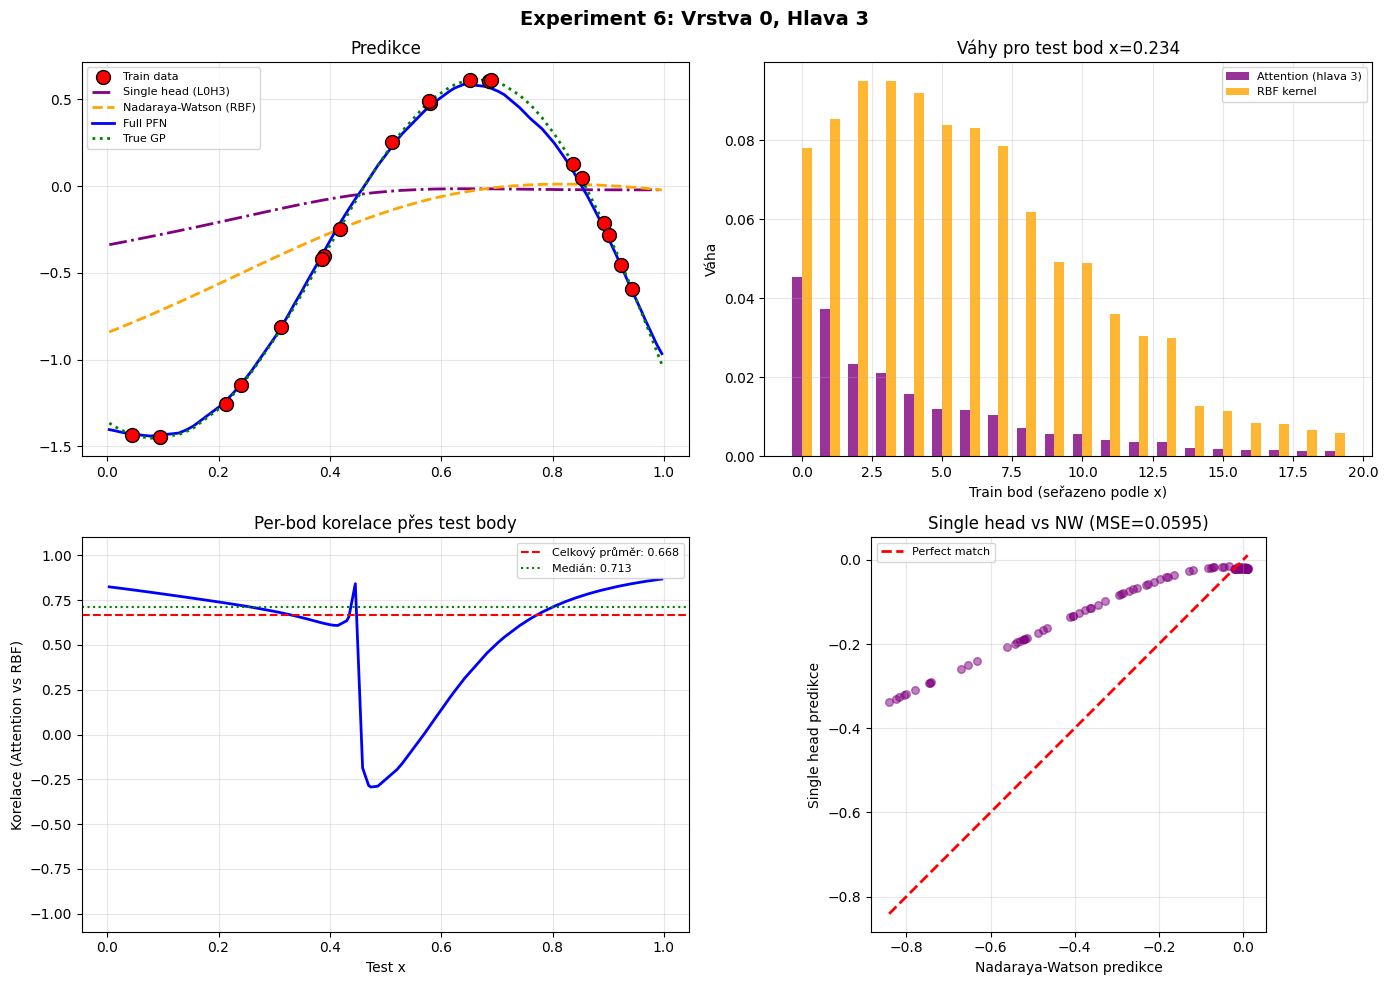


=== VRSTVA 0, HLAVA 7 ===
Korelace attention vs RBF kernel: 0.3513

MSE (Mean Squared Error):
  Single head vs NW:  0.140821
  Single head vs PFN: 0.692351
  Single head vs GP:  0.679337
  NW vs GP:           0.252115
  Full PFN vs GP:     0.000418


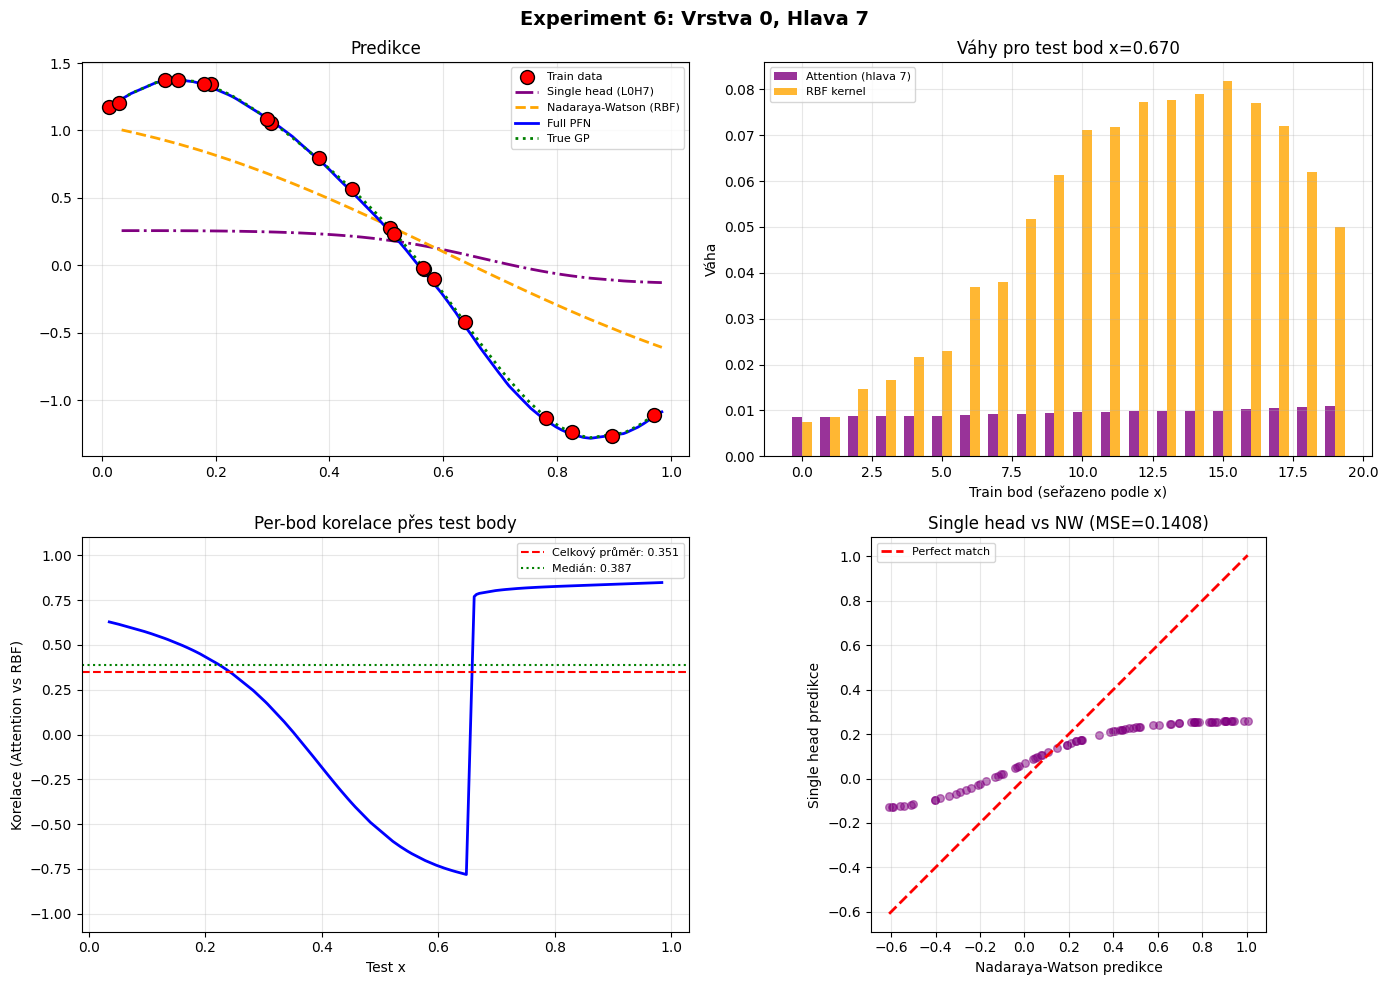


=== VRSTVA 5, HLAVA 0 ===
Korelace attention vs RBF kernel: 0.3109

MSE (Mean Squared Error):
  Single head vs NW:  0.222542
  Single head vs PFN: 0.148191
  Single head vs GP:  0.183390
  NW vs GP:           0.040439
  Full PFN vs GP:     0.002051


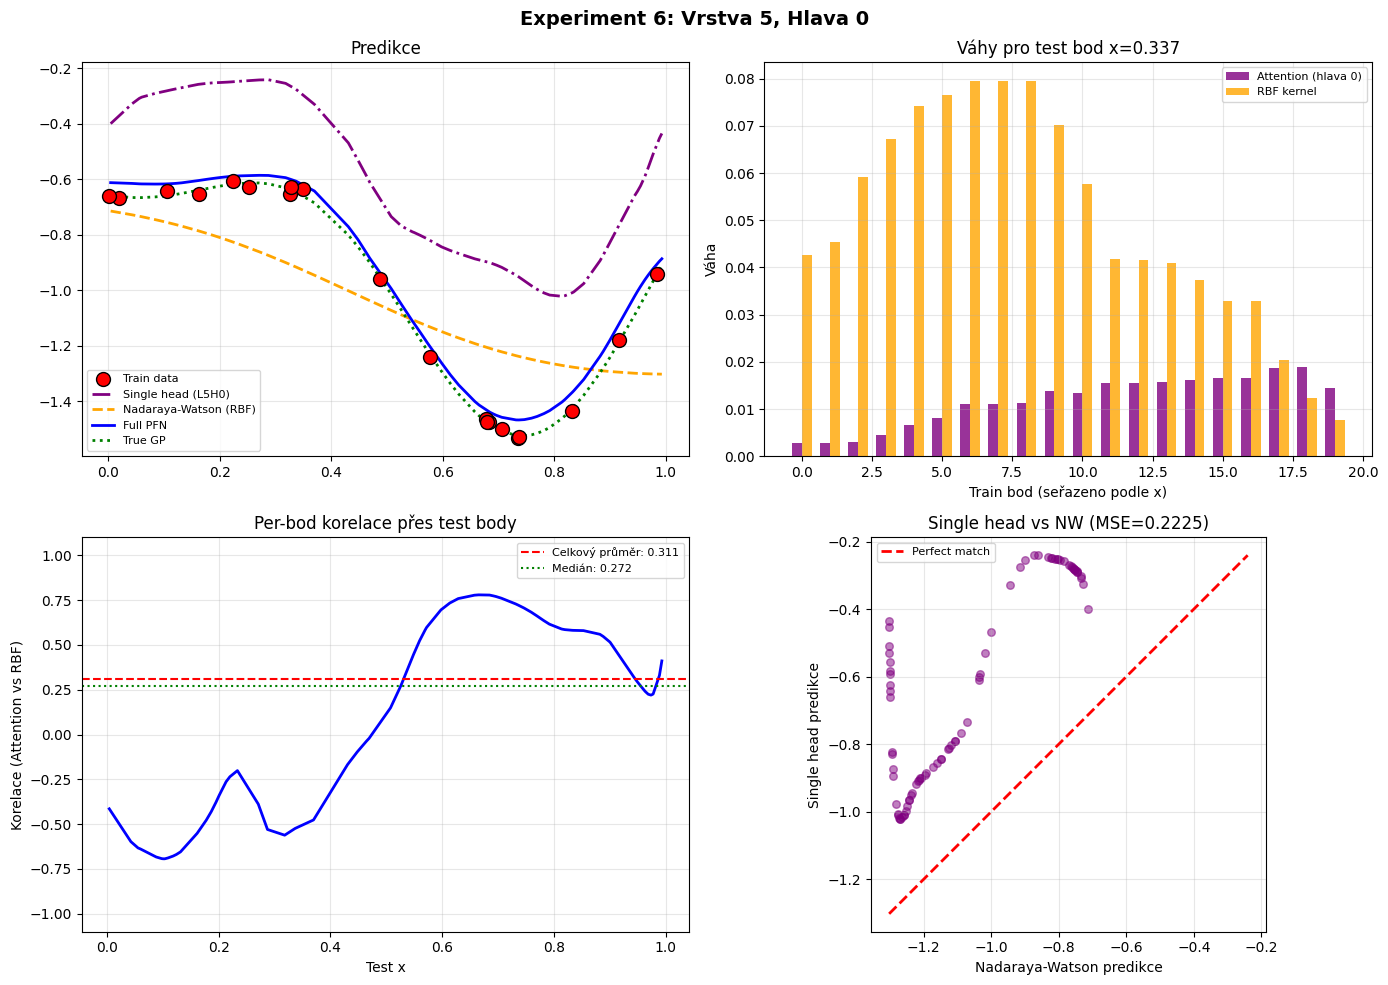


=== VRSTVA 5, HLAVA 3 ===
Korelace attention vs RBF kernel: 0.2737

MSE (Mean Squared Error):
  Single head vs NW:  0.005422
  Single head vs PFN: 0.235206
  Single head vs GP:  0.230763
  NW vs GP:           0.202962
  Full PFN vs GP:     0.000605


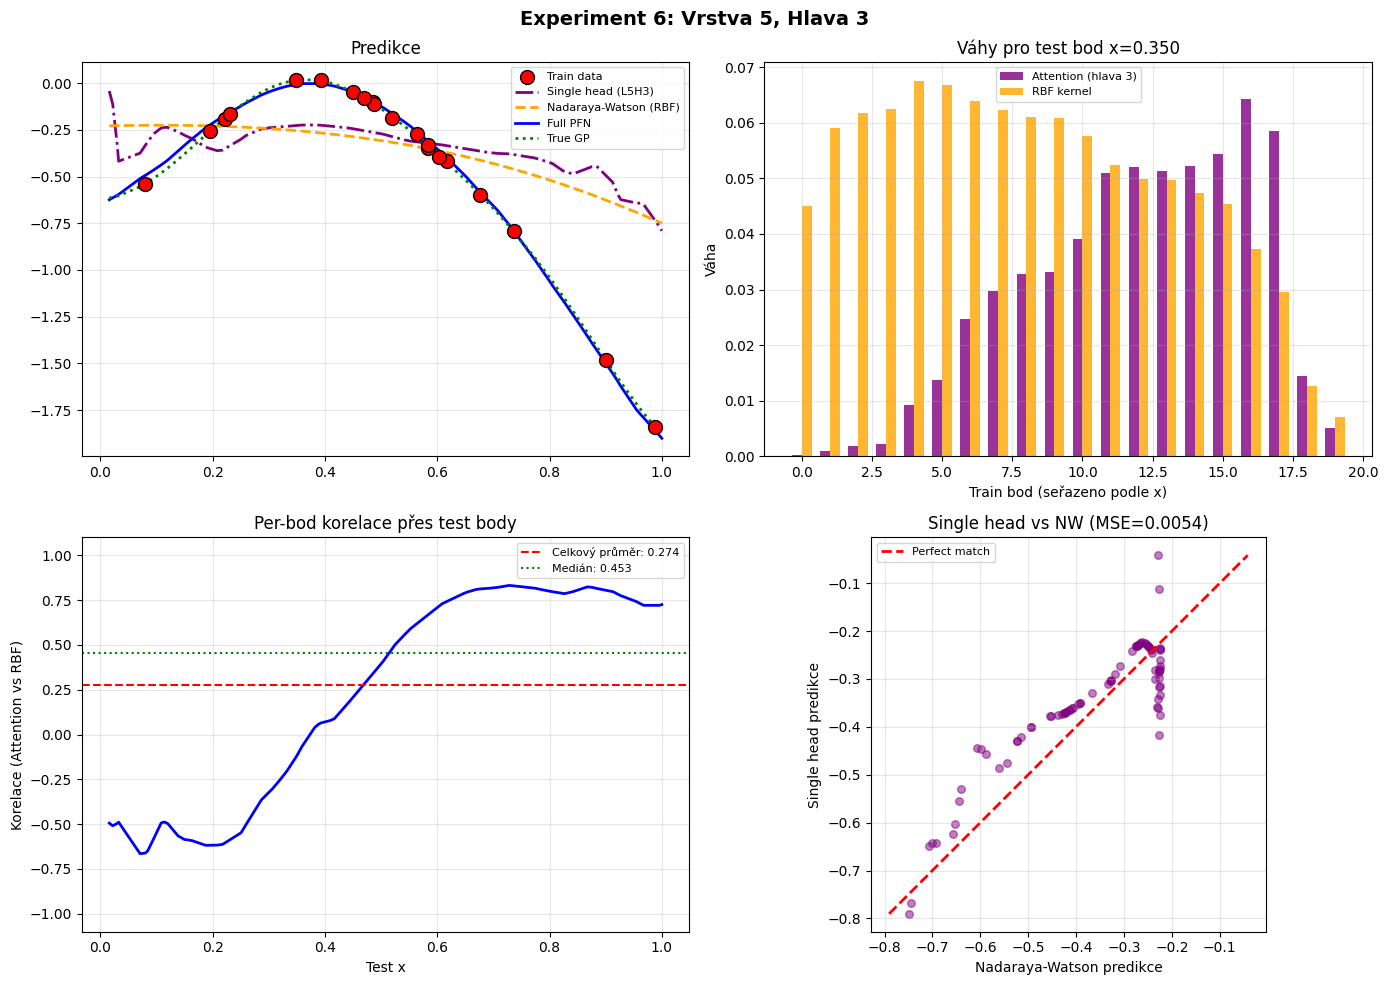


=== VRSTVA 5, HLAVA 7 ===
Korelace attention vs RBF kernel: 0.3179

MSE (Mean Squared Error):
  Single head vs NW:  2.266312
  Single head vs PFN: 2.215422
  Single head vs GP:  2.260626
  NW vs GP:           0.038649
  Full PFN vs GP:     0.000884


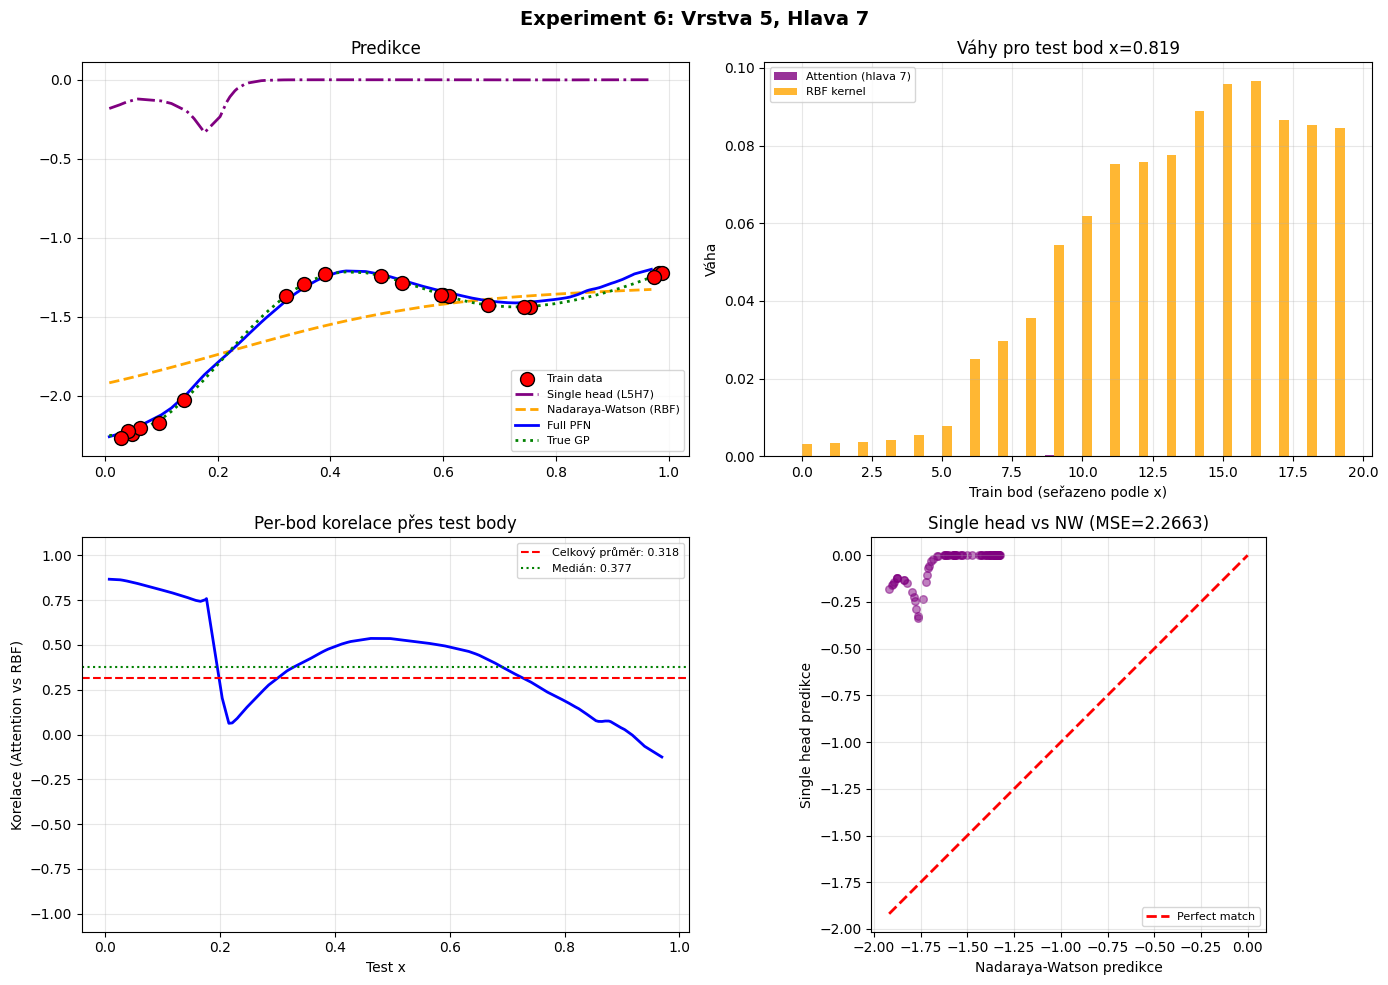


--- Systematický scan všech 48 hlav ---

Trial 1/5...
Trial 2/5...
Trial 3/5...
Trial 4/5...
Trial 5/5...


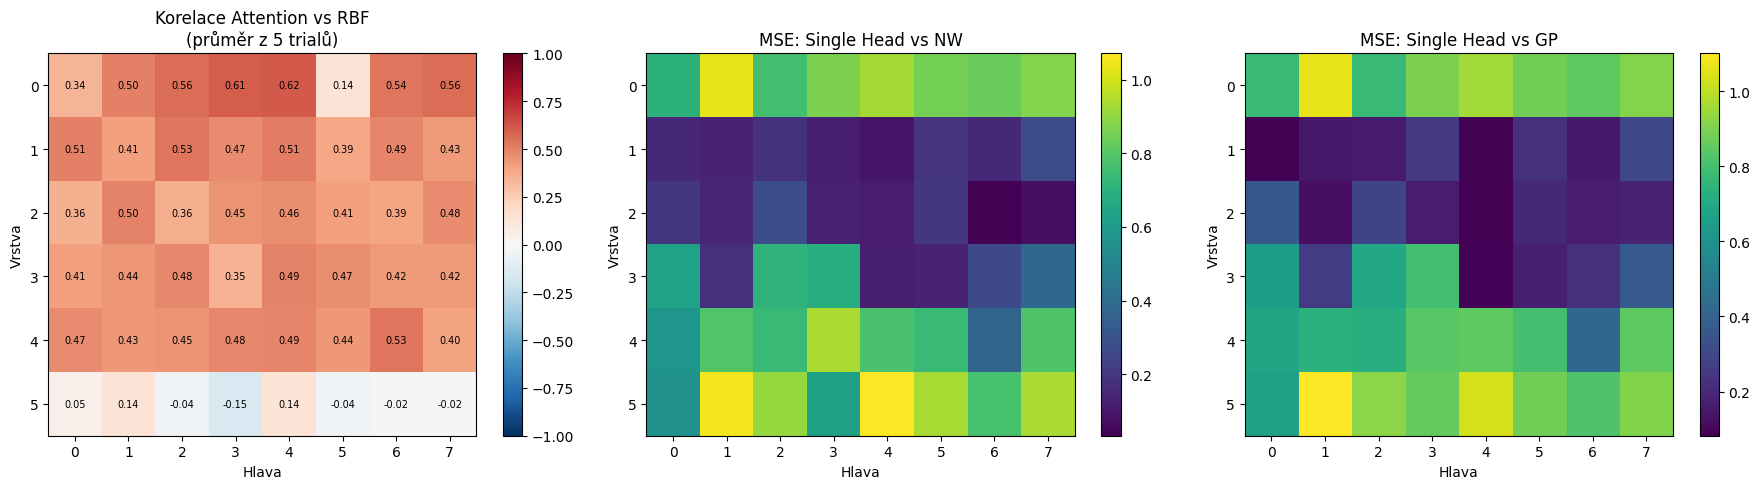


Nejvyšší korelace s RBF: vrstva 0, hlava 4 (corr = 0.6168)

=== KOMPLETNÍ SHRNUTÍ ===
Vrstva   Hlava  Corr(Attn,RBF)     MSE(Head,NW)    MSE(Head,GP)   
--------------------------------------------------------------
0        0      0.3394             0.701304        0.769796       
0        1      0.5040             1.033500        1.066804       
0        2      0.5567             0.761644        0.771107       
0        3      0.6080             0.867880        0.901009       
0        4      0.6168             0.932395        0.960990       
0        5      0.1387             0.855490        0.881312       
0        6      0.5384             0.835657        0.846476       
0        7      0.5589             0.879358        0.913228       
1        0      0.5051             0.149504        0.088313       
1        1      0.4111             0.134761        0.147858       
1        2      0.5346             0.182947        0.154771       
1        3      0.4719             0.118309   

In [ ]:
def extract_single_head_attention(model, train_x, train_y, test_x, layer_idx=0, head_idx=0):
    """
    Extrahuje attention váhy z jedné konkrétní hlavy v jedné vrstvě.

    DŮLEŽITÉ: train_x, train_y, test_x mají být BEZ batch dimenze.
    Funkce compute_attention_weights si [None] přidá sama.
    """
    # ---- FIX #1: Nepřidáváme [None] — to dělá compute_attention_weights ----
    attn_weights_all, _ = compute_attention_weights(
        model, train_x, train_y, test_x
    )

    # attn_weights_all[layer_idx] má tvar [1, 1, n_heads, seq_len, seq_len]
    # Vybereme konkrétní hlavu: [seq_len, seq_len]
    head_attn = attn_weights_all[layer_idx][0, 0, head_idx].detach().numpy()

    return head_attn


def test_single_head_hypothesis(model, hps, layer_idx=0, head_idx=0, n_context=20, seq_len=100):
    """
    Testuje, zda se jedna attention hlava chová jako Nadaraya-Watson estimátor.

    Porovnává:
    - Attention váhy jedné hlavy vs RBF kernel váhy
    - Predikci "attn @ y_train" vs NW predikci vs plný PFN vs true GP
    """

    # === GENERACE DAT ===
    batch = get_batch_for_gp(
        batch_size=1, seq_len=seq_len, num_features=1,
        hyperparameters=hps
    )

    train_x = batch.x[0, :n_context]     # [n_context, 1]
    train_y = batch.y[0, :n_context]      # [n_context]
    test_x = batch.x[0]                   # [seq_len, 1] — celá sekvence

    n_test = seq_len - n_context  # = 80

    # === 1. ATTENTION VÁHY JEDNÉ HLAVY ===
    head_attn = extract_single_head_attention(
        model, train_x, train_y, test_x,
        layer_idx=layer_idx, head_idx=head_idx
    )
    # head_attn má tvar [seq_len, seq_len]

    # Kvadrant Test→Train: jak moc se test body dívají na train body
    # ---- FIX #2: konzistentní indexování ----
    n_train = n_context
    test_to_train_attn = head_attn[n_train + n_context:, :n_train]

    # "Predikce" jedné hlavy: váhovaný průměr train_y pomocí attention vah
    # (to je přesně NW estimátor, pokud kernel = attention kernel)
    train_y_np = train_y.cpu().numpy()
    single_head_pred = test_to_train_attn @ train_y_np  # [n_test]

    # === 2. RBF KERNEL VÁHY ===
    train_x_np = train_x.cpu().numpy().reshape(-1)          # [n_context]
    # ---- FIX #3: RBF váhy POUZE pro test body, ne pro všech seq_len bodů ----
    test_x_only = test_x[n_context:]                         # [n_test, 1]
    test_x_only_np = test_x_only.cpu().numpy().reshape(-1)   # [n_test]

    ls = hps['lengthscale']
    # Vektorizovaný výpočet: [n_test, n_context]
    dists_sq = (test_x_only_np[:, None] - train_x_np[None, :]) ** 2
    rbf_raw = np.exp(-0.5 * dists_sq / ls**2)
    rbf_weights = rbf_raw / rbf_raw.sum(axis=1, keepdims=True)  # normalizace

    # === 3. NADARAYA-WATSON PREDIKCE (s RBF kernelem) ===
    nw_pred = rbf_weights @ train_y_np  # [n_test]

    # === 4. PLNÝ PFN PREDIKCE ===
    with torch.no_grad():
        logits = model(train_x[None], train_y[None], test_x[None])
    pfn_pred_all = model.criterion.mean(logits)[0].cpu().numpy()  # [seq_len]
    pfn_pred = pfn_pred_all[n_context:]  # [n_test] — jen pro test body

    # === 5. TRUE GP PREDIKCE ===
    kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=ls)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
    gp.fit(train_x.cpu().numpy(), train_y_np)
    gp_pred = gp.predict(test_x_only.cpu().numpy())  # [n_test]

    # === ANALÝZA ===
    # Korelace: attention váhy vs RBF kernel váhy (celkově)
    corr_attn_rbf = np.corrcoef(
        test_to_train_attn.flatten(),
        rbf_weights.flatten()
    )[0, 1]

    # MSE predikcí — vše má teď konzistentně tvar [n_test]
    mse_head_vs_nw  = np.mean((single_head_pred - nw_pred) ** 2)
    mse_head_vs_pfn = np.mean((single_head_pred - pfn_pred) ** 2)
    mse_head_vs_gp  = np.mean((single_head_pred - gp_pred) ** 2)
    mse_nw_vs_gp    = np.mean((nw_pred - gp_pred) ** 2)
    mse_pfn_vs_gp   = np.mean((pfn_pred - gp_pred) ** 2)

    print(f"\n=== VRSTVA {layer_idx}, HLAVA {head_idx} ===")
    print(f"Korelace attention vs RBF kernel: {corr_attn_rbf:.4f}")
    print(f"\nMSE (Mean Squared Error):")
    print(f"  Single head vs NW:  {mse_head_vs_nw:.6f}")
    print(f"  Single head vs PFN: {mse_head_vs_pfn:.6f}")
    print(f"  Single head vs GP:  {mse_head_vs_gp:.6f}")
    print(f"  NW vs GP:           {mse_nw_vs_gp:.6f}")
    print(f"  Full PFN vs GP:     {mse_pfn_vs_gp:.6f}")

    # === VIZUALIZACE ===
    # ---- FIX #4: sort POUZE test body ----
    test_order = test_x_only_np.argsort()
    test_x_sorted = test_x_only_np[test_order]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f'Experiment 6: Vrstva {layer_idx}, Hlava {head_idx}',
        fontsize=14, fontweight='bold'
    )

    # ------ Panel 1: Porovnání predikcí ------
    ax = axes[0, 0]
    ax.scatter(train_x_np, train_y_np, c='red', s=100, zorder=10,
               label='Train data', edgecolors='black')
    ax.plot(test_x_sorted, single_head_pred[test_order], 'purple', lw=2,
            label=f'Single head (L{layer_idx}H{head_idx})', linestyle='-.')
    ax.plot(test_x_sorted, nw_pred[test_order], 'orange', lw=2,
            label='Nadaraya-Watson (RBF)', linestyle='--')
    ax.plot(test_x_sorted, pfn_pred[test_order], 'blue', lw=2,
            label='Full PFN')
    ax.plot(test_x_sorted, gp_pred[test_order], 'green', lw=2,
            label='True GP', linestyle=':')
    ax.set_title('Predikce')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ------ Panel 2: Attention váhy vs RBF pro JEDEN test bod ------
    # ---- FIX #5: správně identifikujeme test bod ----
    # Vybereme test bod blízko středu test sady
    mid_test_idx = n_test // 2
    actual_x_value = test_x_only_np[mid_test_idx]

    # Seřadíme train body podle x pro lepší vizualizaci
    train_order = train_x_np.argsort()
    train_x_sorted = train_x_np[train_order]

    ax = axes[0, 1]
    width = 0.35
    indices = np.arange(n_context)
    ax.bar(indices - width/2, test_to_train_attn[mid_test_idx][train_order],
           width, alpha=0.8, label=f'Attention (hlava {head_idx})', color='purple')
    ax.bar(indices + width/2, rbf_weights[mid_test_idx][train_order],
           width, alpha=0.8, label='RBF kernel', color='orange')
    ax.set_xlabel('Train bod (seřazeno podle x)')
    ax.set_ylabel('Váha')
    ax.set_title(f'Váhy pro test bod x={actual_x_value:.3f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ------ Panel 3: Per-test-bod korelace attention vs RBF ------
    ax = axes[1, 0]
    correlations = []
    for i in range(n_test):
        c = np.corrcoef(test_to_train_attn[i], rbf_weights[i])[0, 1]
        correlations.append(c if not np.isnan(c) else 0.0)
    correlations = np.array(correlations)

    ax.plot(test_x_sorted, correlations[test_order], 'b-', lw=2)
    ax.axhline(y=corr_attn_rbf, color='red', linestyle='--',
               label=f'Celkový průměr: {corr_attn_rbf:.3f}')
    ax.axhline(y=np.median(correlations), color='green', linestyle=':',
               label=f'Medián: {np.median(correlations):.3f}')
    ax.set_xlabel('Test x')
    ax.set_ylabel('Korelace (Attention vs RBF)')
    ax.set_title('Per-bod korelace přes test body')
    ax.set_ylim(-1.1, 1.1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ------ Panel 4: Scatter — single head pred vs NW pred ------
    ax = axes[1, 1]
    ax.scatter(nw_pred, single_head_pred, alpha=0.5, s=30, c='purple')
    lims = [min(nw_pred.min(), single_head_pred.min()),
            max(nw_pred.max(), single_head_pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect match')
    ax.set_xlabel('Nadaraya-Watson predikce')
    ax.set_ylabel('Single head predikce')
    ax.set_title(f'Single head vs NW (MSE={mse_head_vs_nw:.4f})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

    return {
        'layer': layer_idx,
        'head': head_idx,
        'corr_attn_rbf': corr_attn_rbf,
        'mse_head_vs_nw': mse_head_vs_nw,
        'mse_head_vs_pfn': mse_head_vs_pfn,
        'mse_head_vs_gp': mse_head_vs_gp,
        'mse_nw_vs_gp': mse_nw_vs_gp,
        'mse_pfn_vs_gp': mse_pfn_vs_gp,
    }


# =============================================
# SYSTEMATICKÝ SCAN: Všechny hlavy ve všech vrstvách
# =============================================

def scan_all_heads(model, hps, n_layers=6, n_heads=8, n_trials=5):
    """
    Systematicky prohledá všechny hlavy ve všech vrstvách.
    Průměruje přes více realizací dat pro robustní výsledky.

    Cíl: najít, které hlavy mají nejvyšší korelaci s RBF kernelem
    (= chovají se nejvíc jako Nadaraya-Watson).
    """
    # Matice výsledků: [n_layers, n_heads]
    corr_matrix = np.zeros((n_layers, n_heads))
    mse_head_nw_matrix = np.zeros((n_layers, n_heads))
    mse_head_gp_matrix = np.zeros((n_layers, n_heads))

    for trial in range(n_trials):
        print(f"Trial {trial+1}/{n_trials}...")

        # Jedno sdílené generování dat pro všechny hlavy v tomto trialu
        batch = get_batch_for_gp(
            batch_size=1, seq_len=100, num_features=1,
            hyperparameters=hps
        )
        n_context = 20
        train_x = batch.x[0, :n_context]
        train_y = batch.y[0, :n_context]
        test_x = batch.x[0]
        n_test = 100 - n_context

        train_y_np = train_y.cpu().numpy()
        train_x_np = train_x.cpu().numpy().reshape(-1)
        test_x_only_np = test_x[n_context:].cpu().numpy().reshape(-1)

        # RBF váhy (společné pro všechny hlavy)
        ls = hps['lengthscale']
        dists_sq = (test_x_only_np[:, None] - train_x_np[None, :]) ** 2
        rbf_raw = np.exp(-0.5 * dists_sq / ls**2)
        rbf_weights = rbf_raw / rbf_raw.sum(axis=1, keepdims=True)
        nw_pred = rbf_weights @ train_y_np

        # GP predikce
        kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=ls)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
        gp.fit(train_x.cpu().numpy(), train_y_np)
        gp_pred = gp.predict(test_x[n_context:].cpu().numpy())

        # Attention váhy — JEDNOU pro celý model (všechny vrstvy naráz)
        attn_weights_all, _ = compute_attention_weights(
            model, train_x, train_y, test_x
        )

        for layer_idx in range(min(n_layers, len(attn_weights_all))):
            for head_idx in range(n_heads):
                head_attn = attn_weights_all[layer_idx][0, 0, head_idx].detach().numpy()
                n_train = n_context
                test_to_train = head_attn[n_train + n_context:, :n_train]

                # Korelace s RBF
                corr = np.corrcoef(test_to_train.flatten(), rbf_weights.flatten())[0, 1]
                if np.isnan(corr):
                    corr = 0.0
                corr_matrix[layer_idx, head_idx] += corr / n_trials

                # Predikce jedné hlavy
                head_pred = test_to_train @ train_y_np
                mse_head_nw_matrix[layer_idx, head_idx] += (
                    np.mean((head_pred - nw_pred)**2) / n_trials
                )
                mse_head_gp_matrix[layer_idx, head_idx] += (
                    np.mean((head_pred - gp_pred)**2) / n_trials
                )

    # === VIZUALIZACE: Heatmapa korelací ===
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    im0 = axes[0].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    axes[0].set_xlabel('Hlava')
    axes[0].set_ylabel('Vrstva')
    axes[0].set_title(f'Korelace Attention vs RBF\n(průměr z {n_trials} trialů)')
    axes[0].set_xticks(range(n_heads))
    axes[0].set_yticks(range(n_layers))
    for i in range(n_layers):
        for j in range(n_heads):
            axes[0].text(j, i, f'{corr_matrix[i,j]:.2f}', ha='center', va='center', fontsize=7)
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(mse_head_nw_matrix, cmap='viridis', aspect='auto')
    axes[1].set_xlabel('Hlava')
    axes[1].set_ylabel('Vrstva')
    axes[1].set_title(f'MSE: Single Head vs NW')
    axes[1].set_xticks(range(n_heads))
    axes[1].set_yticks(range(n_layers))
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(mse_head_gp_matrix, cmap='viridis', aspect='auto')
    axes[2].set_xlabel('Hlava')
    axes[2].set_ylabel('Vrstva')
    axes[2].set_title(f'MSE: Single Head vs GP')
    axes[2].set_xticks(range(n_heads))
    axes[2].set_yticks(range(n_layers))
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

    # Najdi "nejlepší" hlavu (nejvyšší korelace s RBF)
    best_idx = np.unravel_index(corr_matrix.argmax(), corr_matrix.shape)
    print(f"\nNejvyšší korelace s RBF: vrstva {best_idx[0]}, hlava {best_idx[1]} "
          f"(corr = {corr_matrix[best_idx]:.4f})")

    return corr_matrix, mse_head_nw_matrix, mse_head_gp_matrix


# =============================================
# SPUŠTĚNÍ
# =============================================

print("=" * 60)
print("EXPERIMENT 6: Jedna attention hlava vs Nadaraya-Watson")
print("=" * 60)

# Detailní analýza vybraných hlav
print("\n--- Detailní vizualizace pro vybrané hlavy ---\n")
for layer in [0, 5]:        # první a poslední vrstva
    for head in [0, 3, 7]:   # různé hlavy
        result = test_single_head_hypothesis(
            loaded_model, hps,
            layer_idx=layer, head_idx=head
        )

# Systematický scan všech hlav
print("\n--- Systematický scan všech 48 hlav ---\n")
corr_mat, mse_nw_mat, mse_gp_mat = scan_all_heads(
    loaded_model, hps, n_layers=6, n_heads=8, n_trials=5
)

# Výsledná tabulka
print("\n=== KOMPLETNÍ SHRNUTÍ ===")
print(f"{'Vrstva':<8} {'Hlava':<6} {'Corr(Attn,RBF)':<18} {'MSE(Head,NW)':<15} {'MSE(Head,GP)':<15}")
print("-" * 62)
for l in range(6):
    for h in range(8):
        print(f"{l:<8} {h:<6} {corr_mat[l,h]:<18.4f} "
              f"{mse_nw_mat[l,h]:<15.6f} {mse_gp_mat[l,h]:<15.6f}")



*   V tomto experimentu jsme testovali hypotézu, zda jedna attention hlava se chová jako NW.
*   Tato hypotéza se vyvrátila, ale jenom částečně, korelace jsou malé až stření a jenom v první vrstvě významně přesahují přes 0,5. Přesto ale MSE mezi attention hlavou a NW je v prvních vrstvách dost malá, tj. PFN dělá něco jako NW, ale s jiným kernelem než RBF (plyne z korelace)
*   Navíc v poslední vrstvě je vidět, že korelace jsou dokonce záporné, což svědčí o tom, že poslední vrstva dělá něco úplně jiného, než NW.
* Dalším zajímavým pozorováním je to, že ve 2. a 3. vrstvě (v 1. a 2. ve výstupu buňky) je MSE mezi GP a attention hlavou velmi malá, tj. nejspíše v právě těchto vrstvách se dělá většina skutečné aproximace GP.



# Závěr


* PFN se naučil správnou kauzální strukturu GP inference. Testovací body závisí na trénovacích datech (vysoká attention), zatímco trénovací body nezávisí na testovacích (nulová attention). Model tento vztah objevil autonomně z dat bez explicitního zakódování.

* PFN neimplementuje Nadaraya-Watson estimátor (prostý kernel averaging). Nízká korelace s RBF kernelem indikuje, že model aproximuje komplexnější operaci než lokální váhovaný průměr.

* PFN aproximuje true GP posterior s extrémní přesností, zatímco Nadaraya-Watson vykazuje systematické odchylky. Rozdíl o čtyři řády v MSE mezi PFN-GP a NW-GP potvrzuje, že PFN implementuje full Bayesian inference.

* Vliv množství vrstev a velikosti datasetu při trénování na výslednou aproximaci je třeba prozkoumat podrobněji

* PFN se naučil aproximovat kompletní GP posterior formuli: μ(x*) = k(x*, X) @ K^(-1) @ y, nikoli pouze k(x*, X) jako v Nadaraya-Watson estimátoru. Attention mechanismus implicitně implementuje efekt inverze kernel matice K^(-1), která decorreluje blízké trénovací body.

* Jednotlivé hlavy PFN neaproximují NW s RBF kernele, jak jsme předpokládali, ale s nějkým jiným vlastním naučeným kernelem. Celkově se to dá shrnout takto: první vrstvy (0–4): kernel smoothing s naučenými kernely (≈ NW, ale ne s RBF)
Pozdější vrstvy (5): korekce z NW na plný GP posterior (≈ efekt K⁻¹)